# EMiF Project — Has the structure of risk in financial markets changed since COVID-19?

## Section 0 — Data loading and transformations

The goal of this section is to prepare a clean dataset that all subsequent sections
will use without modification. Every transformation is documented and justified here.

This section produces the following objects:
- `prices` — daily prices, forward-filled, full sample, all assets
- `yields` — daily level of the two rate series (US and German 10-year)
- `returns` — daily log-returns, full sample, 12 assets (rates excluded)
- `ret_pre` — log-returns, 2010–2020, main pre-COVID reference period
- `ret_post` — log-returns, 2020–2026, post-COVID regime
- `ret_pre_full` — log-returns, 1990–2020, robustness checks only

### What do we mean by "structure of risk"?

In this project, the structure of risk refers to three distinct but
interconnected dimensions, each corresponding to a set of methods from the
EMiF course:

1. **Risk levels** — the magnitude and persistence of volatility within each
   asset class, measured by GARCH(1,1) parameters (Section 2)

2. **Risk co-movement** — the correlations and covariance structure across
   assets and asset classes, measured by rolling correlations and the DCC
   model (Section 3)

3. **Risk regimes** — whether the change is permanent (structural break) or
   recurring (regime switch), measured by Bai-Perron and Markov-switching
   models (Section 4)

A change in the structure of risk means that at least one of these three
dimensions has shifted significantly and durably after March 2020. Our answer
will be given **by asset class**: Equities, Commodities, Credit and FX.

### On the choice of breakpoint

We set the COVID breakpoint at **23 March 2020**. This date corresponds to the
S&P 500 market bottom and to the Federal Reserve announcement of unlimited
quantitative easing. The VIX also peaked above 80 on that date, a level not
reached since 2008. We are not studying the crash itself but the new risk regime
that emerged after it, so the post-COVID period starts at the market low.
Section 4 will test this choice statistically using the Bai-Perron procedure.

### Why 2010–2020 as the pre-COVID reference period?

Taking everything before March 2020 as the pre-COVID period would include the
Dot-com crash, 9/11 and the Global Financial Crisis — events that are themselves
major structural breaks. A pre-COVID period that already contains three crises is
not a meaningful benchmark.

We instead use **2010–2020**, a decade characterised by low interest rates,
subdued volatility and a long equity bull market. This is the period investors and
risk managers considered normal immediately before COVID. The full 1990–2020
sample is kept as `ret_pre_full` for robustness checks only.

In [407]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import norm
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

# ── Global parameters ─────────────────────────────────────────────────────────
DATA_PATH        = "Data.xlsx"
SHEET            = "Feuil1"
ANNUALIZATION    = 252
COVID_BREAK      = "2020-03-23"
PRE_START        = "2010-01-01"
PRE_START_FULL   = "1990-01-01"
RATE_SERIES      = ["US T 10-year Yield", "German Gov 10-year yield"]

CATEGORIES = {
    "Equities"   : ["S&P500", "Eurostoxx 50", "Hang Seng", "MSCI EM", "SMI"],
    "Commodities": ["Oil futures", "Gold"],
    "FX"         : ["EURUSD", "USDJPY", "USDCHF"],
    "Credit"     : ["US IG Bonds", "US HY Bonds"]
}

COLORS = {
    "pre" : "steelblue",
    "post": "firebrick",
    "full": "dimgray"
}

FIG_DIR = Path("Figures")
TAB_DIR = Path("Tables")
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi"         : 130,
    "axes.spines.top"    : False,
    "axes.spines.right"  : False,
    "axes.grid"          : True,
    "grid.alpha"         : 0.3,
    "font.size"          : 11
})

print("Libraries and parameters loaded.")

Libraries and parameters loaded.


### 0.1 Loading and cleaning the data

Missing values come from calendar mismatches between markets — US, European
and Asian exchanges do not share the same holidays. The standard treatment is
to forward-fill: the last observed price is carried forward until the next
available observation.

Oil futures prices briefly turned negative in April 2020. Non-positive prices
are treated as missing and forward-filled before computing log-returns.

Log-returns are defined as $r_{i,t} = \log(P_{i,t}) - \log(P_{i,t-1})$. They
are preferred over simple returns because they are approximately stationary,
time-additive and symmetric around zero — properties required for GARCH
estimation.

Rate series are stored separately as levels. Computing log-differences on
yields that approached zero (the German yield was negative from 2015 to 2020)
produces economically meaningless values. A yield moving from 0.10% to 0.05%
generates a log-return of -69%, which bears no relationship to the actual
market move.

In [408]:
def load_data(path, sheet, rate_series, pre_start, pre_start_full, covid_break):
    raw = pd.read_excel(path, sheet_name=sheet, index_col=0, parse_dates=True)
    raw = raw.sort_index().ffill()

    missing_before = (raw.isnull().sum() / len(raw) * 100).round(1)

    yields      = raw[rate_series].copy()
    non_rate    = [c for c in raw.columns if c not in rate_series]
    prices_     = raw[non_rate].where(raw[non_rate] > 0).ffill().dropna(how="any")
    returns_    = np.log(prices_).diff().dropna()

    ret_pre      = returns_.loc[pre_start : pd.Timestamp(covid_break) - pd.Timedelta(days=1)]
    ret_post     = returns_.loc[covid_break:]
    ret_pre_full = returns_.loc[pre_start_full : pd.Timestamp(covid_break) - pd.Timedelta(days=1)]

    return raw, yields, returns_, ret_pre, ret_post, ret_pre_full, missing_before, prices_

prices, yields, returns, ret_pre, ret_post, ret_pre_full, missing_before, prices_raw = load_data(
    DATA_PATH, SHEET, RATE_SERIES, PRE_START, PRE_START_FULL, COVID_BREAK
)

print(f"Full sample      : {returns.index.min().date()} to {returns.index.max().date()} ({len(returns)} obs)")
print(f"Pre-COVID        : {ret_pre.index.min().date()} to {ret_pre.index.max().date()} ({len(ret_pre)} obs)")
print(f"Post-COVID       : {ret_post.index.min().date()} to {ret_post.index.max().date()} ({len(ret_post)} obs)")
print(f"Pre-COVID full   : {ret_pre_full.index.min().date()} to {ret_pre_full.index.max().date()} ({len(ret_pre_full)} obs)")
print(f"\nAssets in returns ({len(returns.columns)}): {list(returns.columns)}")
print(f"Rate series ({len(yields.columns)}): {list(yields.columns)}")
print(f"\nGerman Gov yield — min     : {yields['German Gov 10-year yield'].min():.4f}")
print(f"German Gov yield — nb neg  : {(yields['German Gov 10-year yield'] < 0).sum()}")

Full sample      : 1990-01-04 to 2026-04-24 (9597 obs)
Pre-COVID        : 2010-01-01 to 2020-03-20 (2702 obs)
Post-COVID       : 2020-03-23 to 2026-04-24 (1611 obs)
Pre-COVID full   : 1990-01-04 to 2020-03-20 (7986 obs)

Assets in returns (12): ['S&P500', 'Eurostoxx 50', 'Hang Seng', 'MSCI EM', 'SMI', 'Oil futures', 'Gold', 'EURUSD', 'USDJPY', 'US IG Bonds', 'US HY Bonds', 'USDCHF']
Rate series (2): ['US T 10-year Yield', 'German Gov 10-year yield']

German Gov yield — min     : -0.8556
German Gov yield — nb neg  : 813


### 0.2 Dataset overview

In [409]:
# Missing values
print("Missing values before treatment (%):\n")
print(missing_before.to_string())
missing_before.to_csv(TAB_DIR / "tab0_missing_values.csv")

# Assets by category
print("\nAssets by category:")
for cat, assets in CATEGORIES.items():
    available = [a for a in assets if a in returns.columns]
    print(f"  {cat:15}: {', '.join(available)}")
print(f"\nRate series (stored as levels):")
for r in RATE_SERIES:
    print(f"  {r}")

Missing values before treatment (%):

S&P500                      0.0
Eurostoxx 50                0.0
Hang Seng                   0.0
MSCI EM                     0.0
SMI                         0.0
US T 10-year Yield          0.0
German Gov 10-year yield    0.0
Oil futures                 0.0
Gold                        0.0
EURUSD                      0.0
USDJPY                      0.0
US IG Bonds                 0.0
US HY Bonds                 0.0
USDCHF                      0.0

Assets by category:
  Equities       : S&P500, Eurostoxx 50, Hang Seng, MSCI EM, SMI
  Commodities    : Oil futures, Gold
  FX             : EURUSD, USDJPY, USDCHF
  Credit         : US IG Bonds, US HY Bonds

Rate series (stored as levels):
  US T 10-year Yield
  German Gov 10-year yield


### 0.3 Cumulative returns and yield levels

Each panel covers one asset class. The vertical dashed line marks the COVID
breakpoint at 23 March 2020. Rate series are displayed as yield levels — the
economically meaningful representation for interest rates.

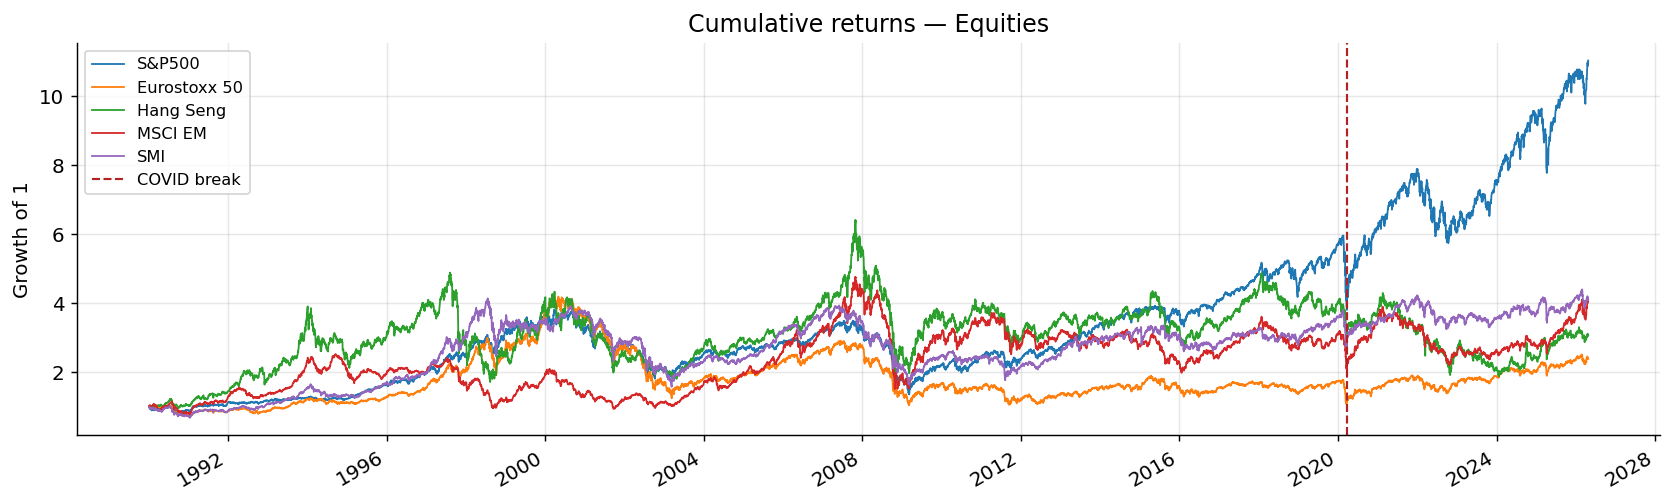

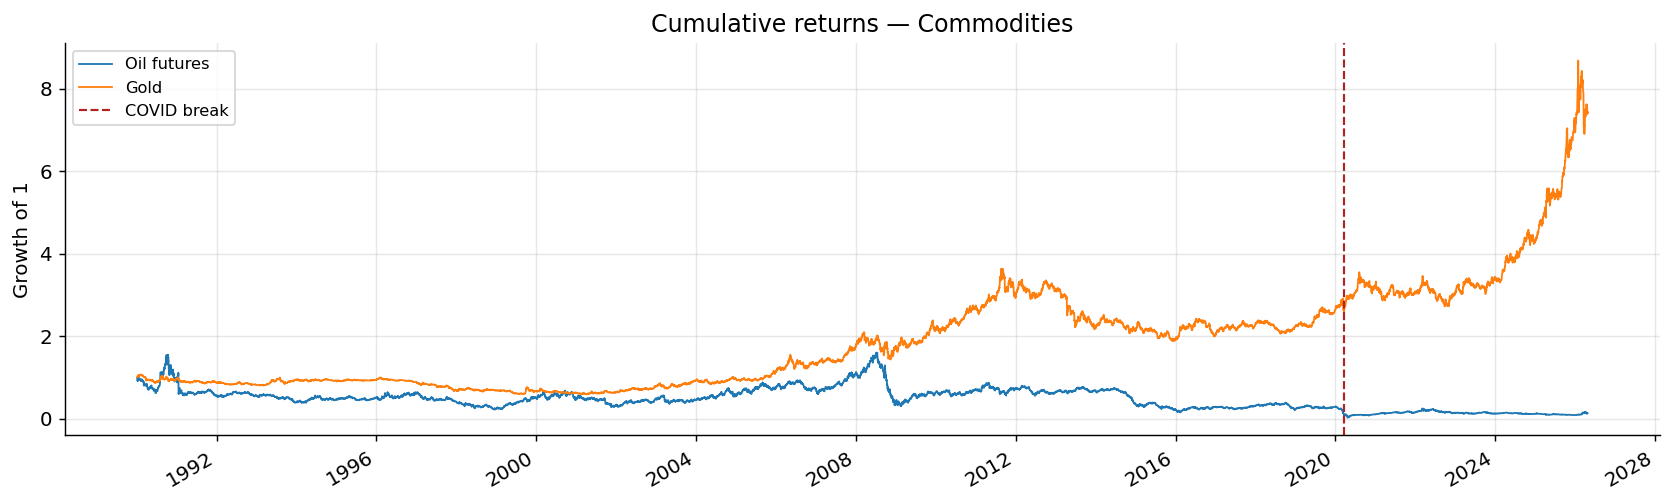

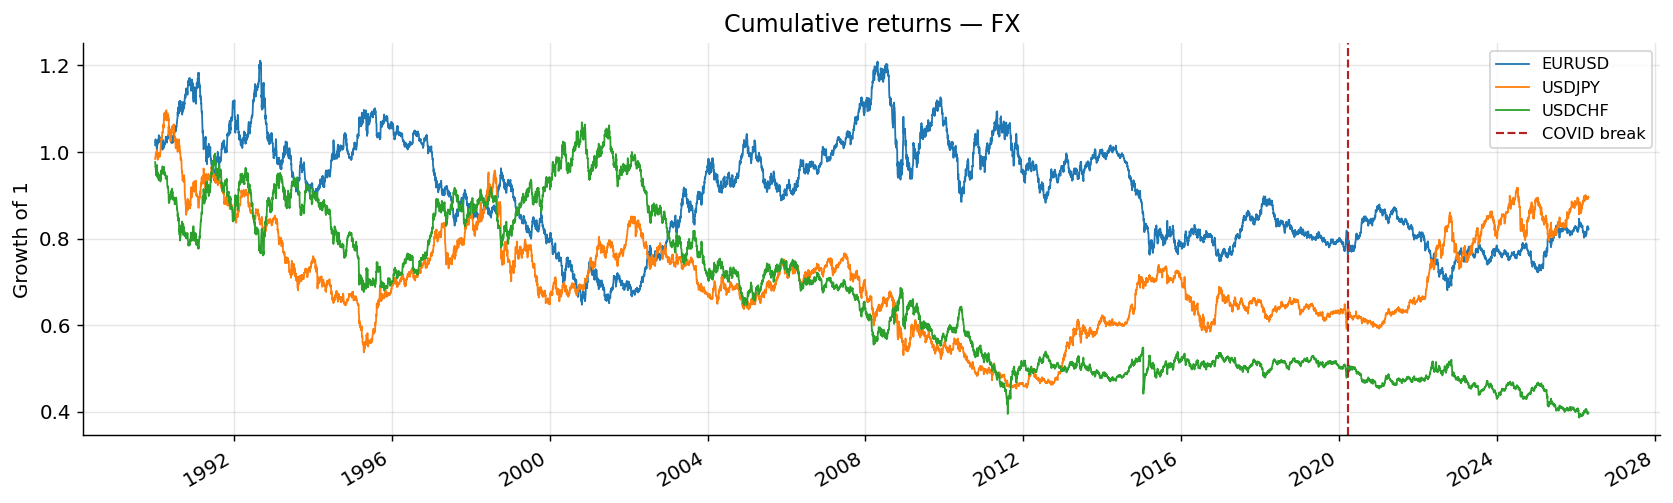

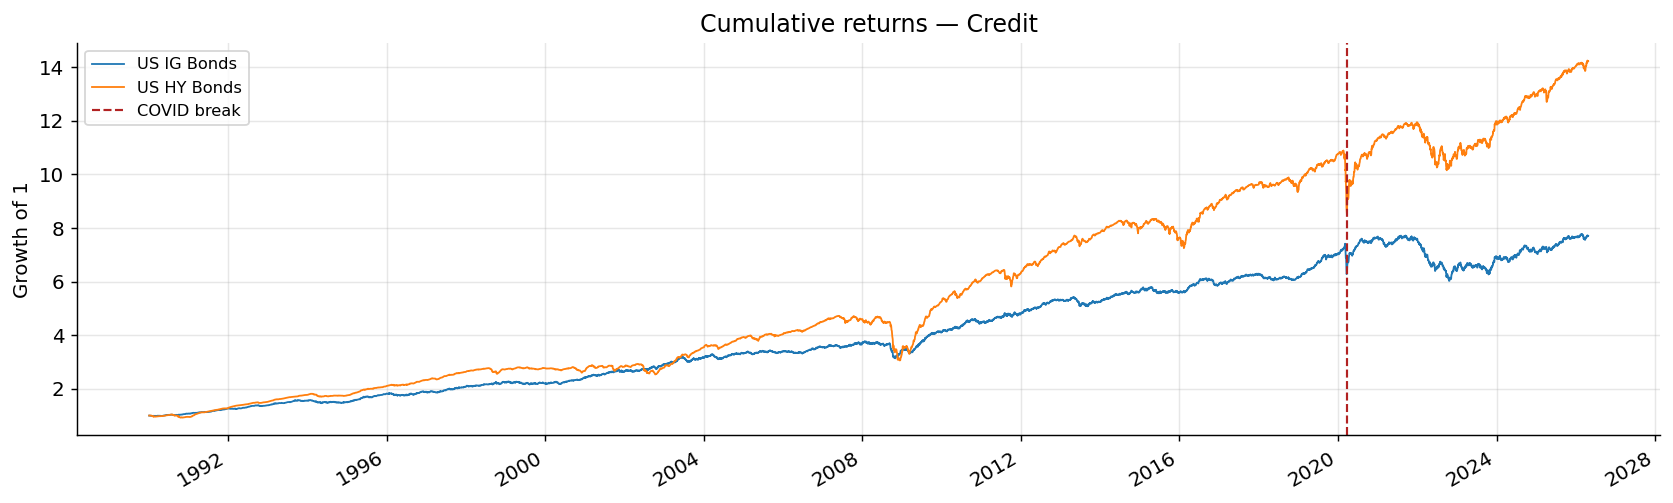

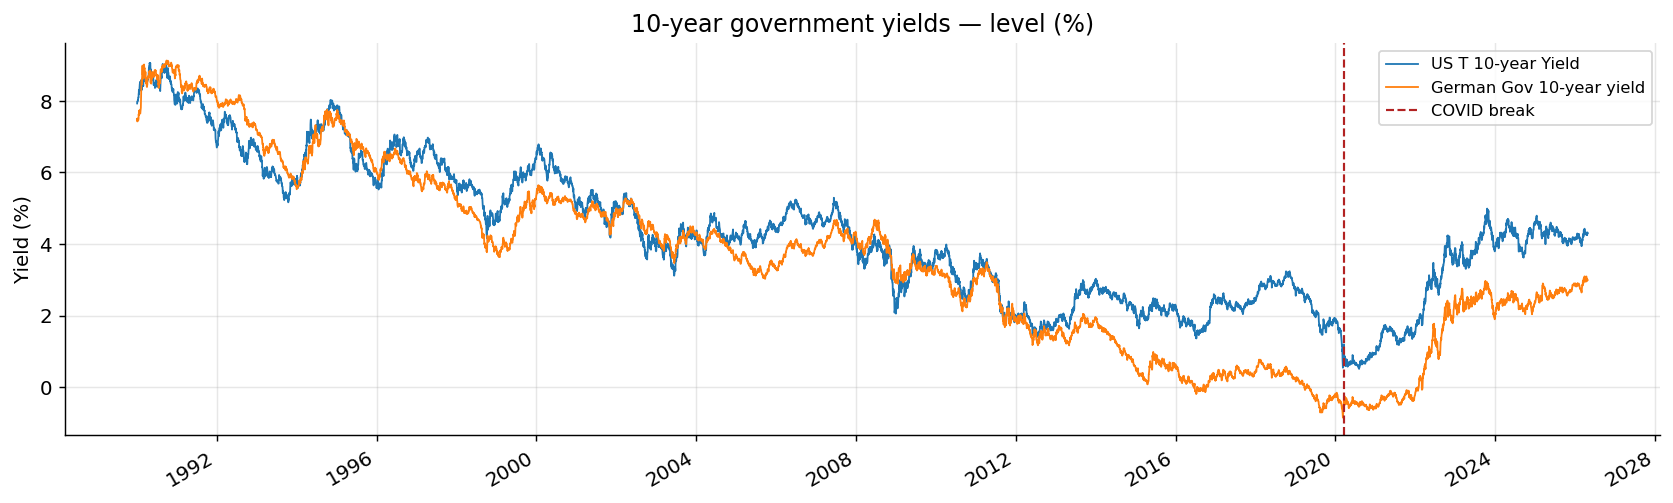

In [410]:
for cat, assets in CATEGORIES.items():
    available = [a for a in assets if a in returns.columns]
    cum = (1 + returns[available]).cumprod()
    fig, ax = plt.subplots(figsize=(13, 4))
    cum.plot(ax=ax, linewidth=1)
    ax.axvline(pd.Timestamp(COVID_BREAK), color="firebrick",
               linestyle="--", linewidth=1.2, label="COVID break")
    ax.set_title(f"Cumulative returns — {cat}")
    ax.set_ylabel("Growth of 1")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig0_cumret_{cat.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
yields.plot(ax=ax, linewidth=1)
ax.axvline(pd.Timestamp(COVID_BREAK), color="firebrick",
           linestyle="--", linewidth=1.2, label="COVID break")
ax.set_title("10-year government yields — level (%)")
ax.set_ylabel("Yield (%)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig0_yields_level.png", dpi=150, bbox_inches="tight")
plt.show()

### 0.4 Descriptive statistics by asset class

We compare the first four moments of each return series across the two
periods. Annualised volatility measures the level of risk. Skewness measures
asymmetry and left-tail exposure. Excess kurtosis measures tail thickness
relative to a Gaussian distribution. The minimum daily return captures the
worst tail event in each period.

In [411]:
def desc_stats(ret):
    return pd.DataFrame({
        "Ann. Vol (%)"   : (ret.std() * np.sqrt(ANNUALIZATION) * 100).round(2),
        "Skewness"       : ret.apply(stats.skew).round(3),
        "Kurt. (excess)" : ret.apply(stats.kurtosis).round(3),
        "Min return (%)" : (ret.min() * 100).round(2),
    })

combined = pd.concat(
    [desc_stats(ret_pre), desc_stats(ret_post)],
    axis=1,
    keys=["Pre-COVID (2010-2020)", "Post-COVID (2020-2026)"]
)
combined.to_csv(TAB_DIR / "tab0_descriptive_stats.csv")
combined

Pre-COVID (2010-2020)                                         \
                      Ann. Vol (%) Skewness Kurt. (excess) Min return (%)   
S&P500                       16.29   -1.358         19.204         -12.77   
Eurostoxx 50                 20.12   -0.747          9.275         -13.24   
Hang Seng                    17.72   -0.336          2.724          -6.02   
MSCI EM                      15.68   -0.695          4.744          -6.94   
SMI                          15.17   -1.112         10.911         -10.13   
Oil futures                  35.51   -1.169         23.672         -28.22   
Gold                         15.10   -0.648          6.430          -9.51   
EURUSD                        8.73   -0.026          1.891          -2.41   
USDJPY                        9.06   -0.018          5.118          -3.78   
US IG Bonds                   4.49   -1.904         18.531          -3.83   
US HY Bonds                   4.32   -4.323         49.492          -3.68   
USDCHF                       11.10   -7.104        229.310         -19.38   

             Post-COVID (2020-2026)                                         
                       Ann. Vol (%) Skewness Kurt. (excess) Min return (%)  
S&P500                        17.86    0.320          8.199          -6.16  
Eurostoxx 50                  18.38    0.176          5.479          -5.09  
Hang Seng                     23.82   -0.373          7.872         -14.18  
MSCI EM                       16.68   -0.263          5.066          -8.25  
SMI                           13.97   -0.310          6.212          -5.52  
Oil futures                   52.89   -3.141         78.893         -60.17  
Gold                          17.20   -0.667          6.606          -9.37  
EURUSD                         7.33    0.219          1.547          -1.86  
USDJPY                         9.13   -0.565          4.020          -3.86  
US IG Bonds                    5.88    0.083          1.933          -1.80  
US HY Bonds                    5.31    0.882         16.096          -2.39  
USDCHF                         7.76   -0.689          4.448          -3.91

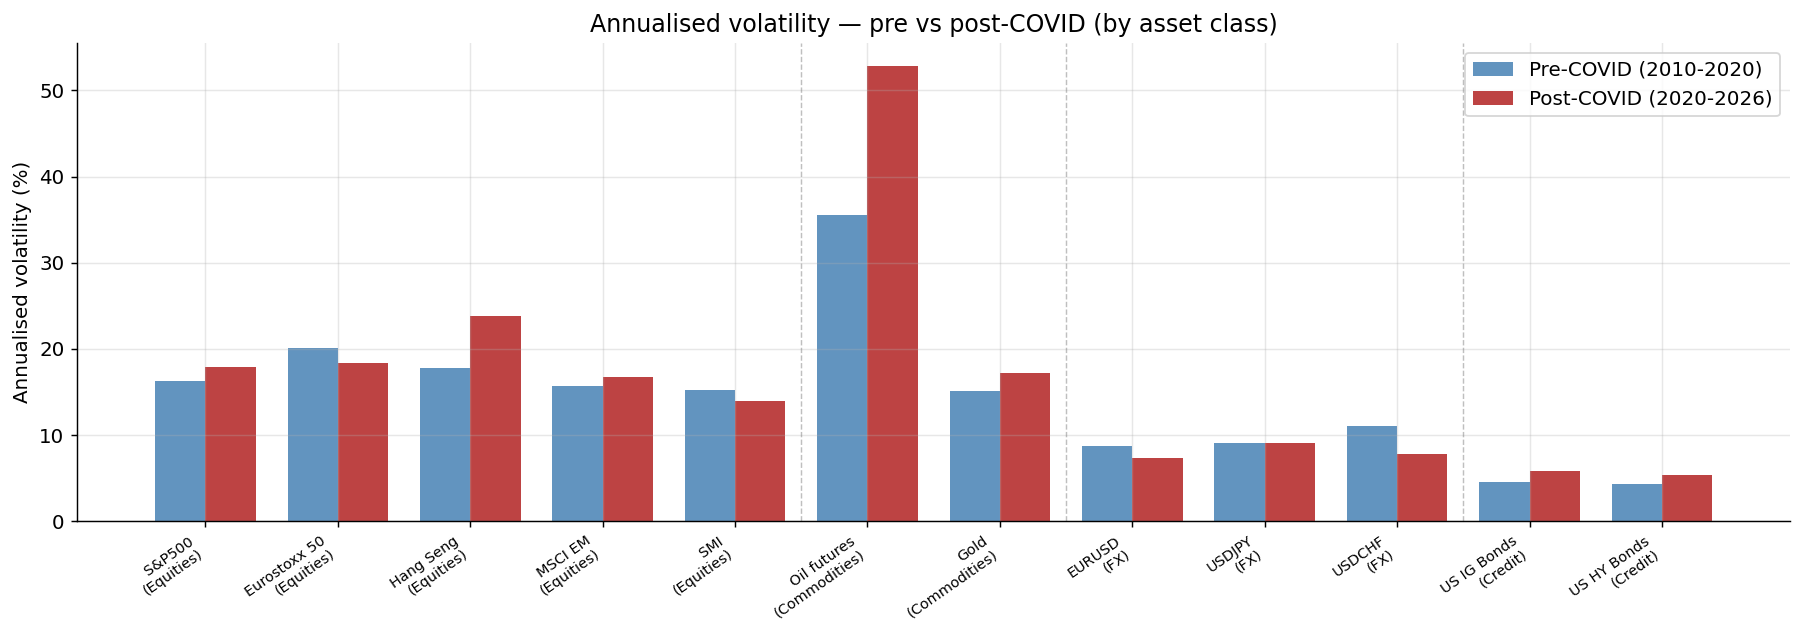

In [412]:
# Organize by asset class
ordered_assets = []
ordered_labels = []
for cat, assets in CATEGORIES.items():
    for a in assets:
        if a in returns.columns:
            ordered_assets.append(a)
            ordered_labels.append(f"{a}\n({cat})")

vol_pre_ordered  = ret_pre[ordered_assets].std()  * np.sqrt(ANNUALIZATION) * 100
vol_post_ordered = ret_post[ordered_assets].std() * np.sqrt(ANNUALIZATION) * 100

x     = np.arange(len(ordered_assets))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, vol_pre_ordered,  width,
       label="Pre-COVID (2010-2020)",  color=COLORS["pre"],  alpha=0.85)
ax.bar(x + width/2, vol_post_ordered, width,
       label="Post-COVID (2020-2026)", color=COLORS["post"], alpha=0.85)


boundaries = []
count = 0
for cat, assets in CATEGORIES.items():
    count += len([a for a in assets if a in returns.columns])
    boundaries.append(count - 0.5)
for b in boundaries[:-1]:
    ax.axvline(b, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(ordered_labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Annualised volatility (%)")
ax.set_title("Annualised volatility — pre vs post-COVID (by asset class)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig0_vol_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 0.5 Summary

The dataset covers 12 assets across four asset classes and two rate series,
from 1990 to April 2026. The pre-COVID reference period is 2010–2020 and the
post-COVID period starts on 23 March 2020.

The volatility chart already reveals a heterogeneous picture:
- **Equities**: modest increase post-COVID, with Hang Seng most affected
- **Commodities**: Oil futures show the largest shift, reflecting the April
  2020 price collapse and the 2022 geopolitical shocks
- **Credit**: slight increase consistent with the post-COVID rate hiking cycle
- **FX**: relatively stable, with USDCHF showing a decrease as the 2015 SNB
  flash crash no longer distorts the post-COVID sample

This heterogeneity motivates a **response to the research question by asset
class** rather than a single global answer.

## Section 1 — Stylized facts

Before estimating any model, we document that the return series exhibit the
classical properties of financial data and test whether these properties have
changed between the two periods. This section gives a model-free first answer
to the research question and motivates the GARCH estimation in Section 2.

The analysis follows the workflow of the Class 9 notebook: volatility proxies,
autocorrelation structure, formal ARCH tests and excess kurtosis. All results
are presented **by asset class** to allow a direct comparison across categories.

### 1.1 Simple volatility proxies

Before any formal test, we compare three simple proxies for time-varying
volatility for a representative asset in each class: S&P 500 (Equities),
Oil futures (Commodities), US HY Bonds (Credit) and EURUSD (FX).

The three proxies are:
- **Rolling 20-day volatility**: captures short-term fluctuations
- **Rolling 60-day volatility**: smoother, captures medium-term trends
- **EWMA volatility** (λ = 0.94): the RiskMetrics standard, gives more
  weight to recent observations

These proxies motivate the use of GARCH models in Section 2: if volatility
were constant, all three proxies would be flat. The persistence and level
of these proxies already suggest whether the post-COVID regime differs.

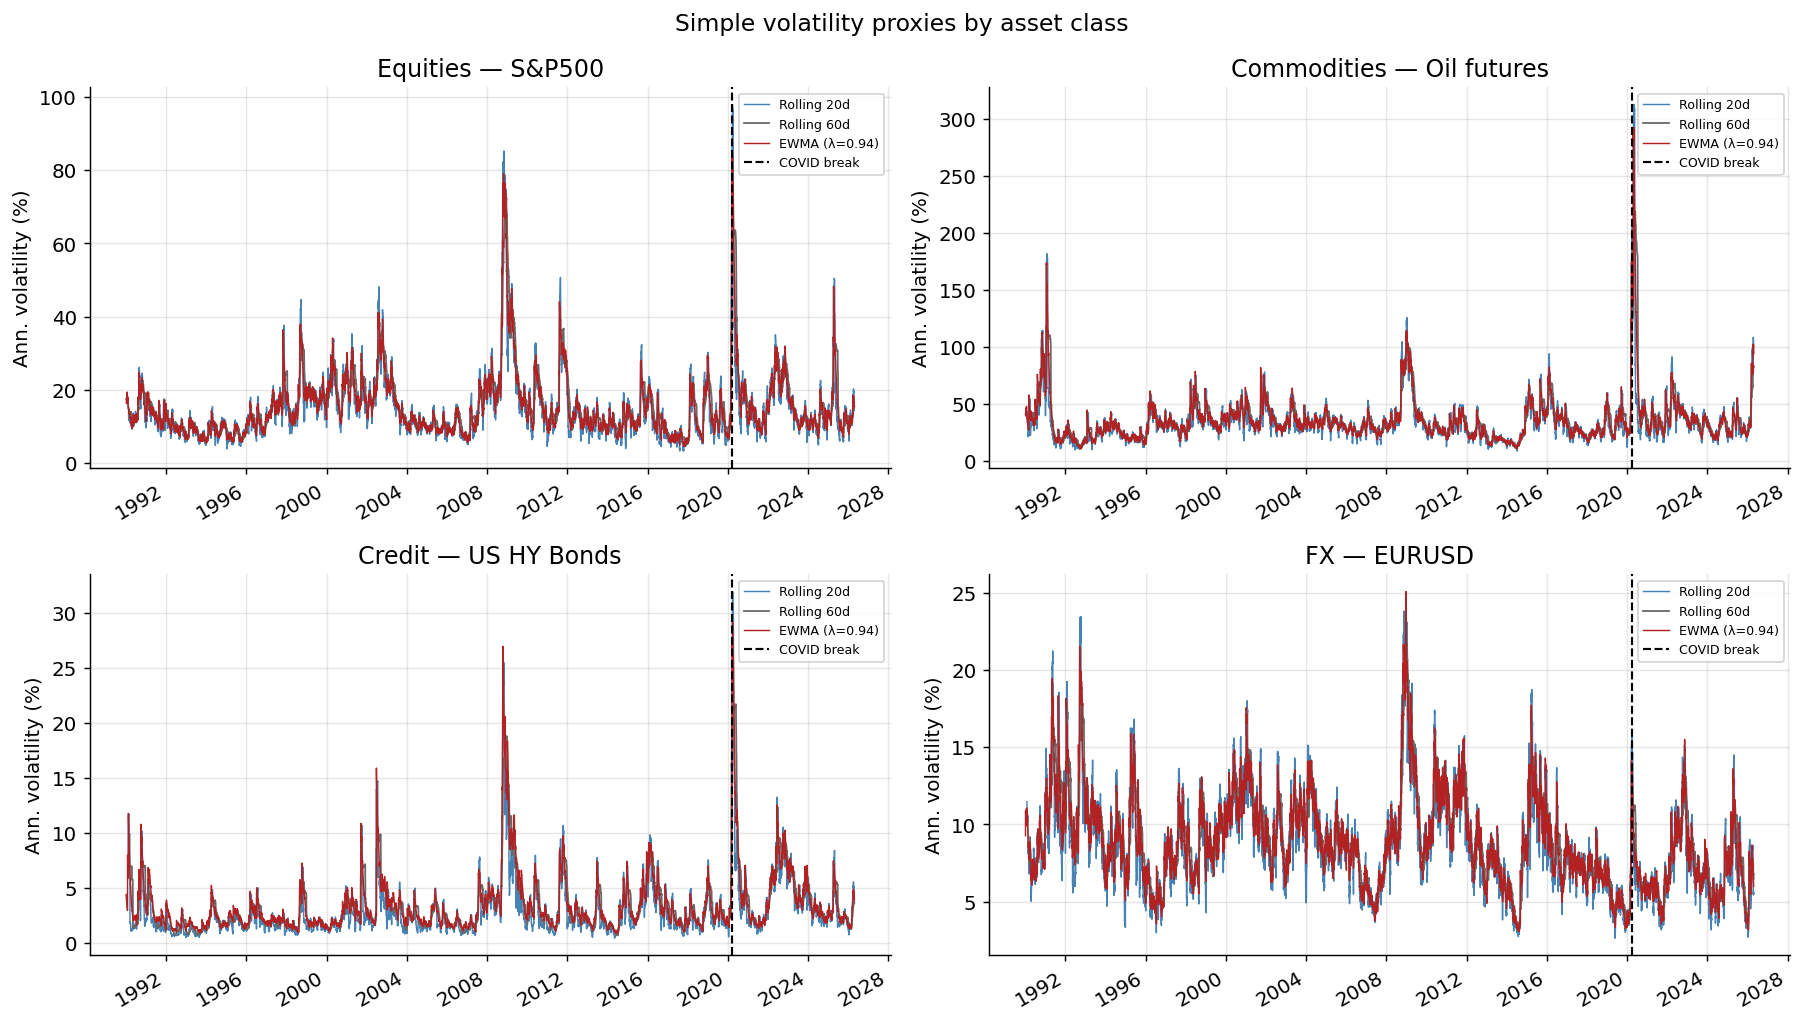

In [413]:
def ewma_vol(r, lam=0.94):
    r = np.asarray(r)
    sigma2 = np.empty_like(r)
    sigma2[0] = np.var(r)
    for t in range(1, len(r)):
        sigma2[t] = lam * sigma2[t-1] + (1 - lam) * r[t-1]**2
    return np.sqrt(sigma2) * np.sqrt(ANNUALIZATION) * 100

representatives = {
    "Equities"   : "S&P500",
    "Commodities": "Oil futures",
    "Credit"     : "US HY Bonds",
    "FX"         : "EURUSD"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.flatten()

for idx, (cat, asset) in enumerate(representatives.items()):
    series = returns[asset].dropna()
    roll20 = series.rolling(20).std() * np.sqrt(ANNUALIZATION) * 100
    roll60 = series.rolling(60).std() * np.sqrt(ANNUALIZATION) * 100
    ewma   = pd.Series(ewma_vol(series.values), index=series.index)

    ax = axes[idx]
    roll20.plot(ax=ax, linewidth=0.8, label="Rolling 20d", color="steelblue")
    roll60.plot(ax=ax, linewidth=1.0, label="Rolling 60d", color="dimgray")
    ewma.plot(ax=ax,   linewidth=0.8, label="EWMA (λ=0.94)", color="firebrick")
    ax.axvline(pd.Timestamp(COVID_BREAK), color="black",
               linestyle="--", linewidth=1.2, label="COVID break")
    ax.set_title(f"{cat} — {asset}")
    ax.set_ylabel("Ann. volatility (%)")
    ax.legend(fontsize=7)

fig.suptitle("Simple volatility proxies by asset class", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_vol_proxies.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.2 Autocorrelation structure

Raw returns should have little autocorrelation if markets are approximately
efficient. Squared returns, however, should display significant positive
autocorrelation if volatility clustering is present — this is the core
empirical motivation for ARCH-type models, first documented by Engle (1982).

We report the first-order autocorrelation of squared returns for all 12
assets in both periods. A high ACF(1) indicates strong short-term volatility
persistence. Reading across the two periods shows whether clustering has
strengthened or weakened since COVID-19.



In [414]:
acf_summary = []
for asset in returns.columns:
    acf_pre  = pd.Series(ret_pre[asset].dropna()**2).autocorr(lag=1)
    acf_post = pd.Series(ret_post[asset].dropna()**2).autocorr(lag=1)
    
    # Identifier la classe
    cat = next((c for c, assets in CATEGORIES.items() 
                if asset in assets), "Other")
    
    acf_summary.append({
        "Asset class"    : cat,
        "Asset"          : asset,
        "ACF(1) Pre-COVID" : round(acf_pre, 3),
        "ACF(1) Post-COVID": round(acf_post, 3),
        "Change"         : "↓" if acf_post < acf_pre else "↑"
    })

acf_df = pd.DataFrame(acf_summary).set_index(["Asset class", "Asset"])
acf_df.to_csv(TAB_DIR / "tab1_acf_summary.csv")
acf_df

ACF(1) Pre-COVID  ACF(1) Post-COVID Change
Asset class Asset                                                   
Equities    S&P500                   0.546              0.144      ↓
            Eurostoxx 50             0.105              0.144      ↑
            Hang Seng                0.103              0.085      ↓
            MSCI EM                  0.135              0.202      ↑
            SMI                      0.232              0.475      ↑
Commodities Oil futures              0.376              0.266      ↓
            Gold                     0.167              0.103      ↓
FX          EURUSD                   0.130              0.148      ↑
            USDJPY                   0.134              0.082      ↓
Credit      US IG Bonds              0.481              0.177      ↓
            US HY Bonds              0.230              0.245      ↑
FX          USDCHF                   0.013              0.109      ↑

### 1.3 Formal tests for ARCH effects

Visual inspection of the ACF is useful but not sufficient. We complement it
with two formal tests applied to all 12 assets in both periods:

- **Ljung-Box test** on squared returns: tests whether $r_t^2$ is
  autocorrelated up to lag 10
- **ARCH-LM test** (Engle, 1982): Lagrange multiplier test of the null
  hypothesis of no conditional heteroskedasticity

Rejecting the null on both tests confirms that volatility clustering is
present and that a constant variance model would be misspecified. This
justifies the GARCH approach in Section 2.

In [415]:
results = []
for asset in returns.columns:
    cat = next((c for c, lst in CATEGORIES.items() if asset in lst), "Other")
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series = ret[asset].dropna()
        lb     = acorr_ljungbox(series**2, lags=[10], return_df=True)
        lm     = het_arch(series, nlags=10)
        results.append({
            "Asset class"    : cat,
            "Asset"          : asset,
            "Period"         : label,
            "LB stat"        : round(lb["lb_stat"].values[0], 2),
            "LB p-value"     : round(lb["lb_pvalue"].values[0], 4),
            "ARCH-LM stat"   : round(lm[0], 2),
            "ARCH-LM p-value": round(lm[1], 4)
        })

tests_df = pd.DataFrame(results).set_index(["Asset class", "Asset", "Period"])
tests_df.to_csv(TAB_DIR / "tab1_arch_tests.csv")
tests_df

LB stat  LB p-value  ARCH-LM stat  \
Asset class Asset        Period                                          
Equities    S&P500       Pre-COVID   2696.97       0.000       1176.87   
                         Post-COVID   387.56       0.000        242.97   
            Eurostoxx 50 Pre-COVID    527.58       0.000        323.15   
                         Post-COVID   284.40       0.000        183.73   
            Hang Seng    Pre-COVID    413.67       0.000        224.92   
                         Post-COVID    49.82       0.000         33.50   
            MSCI EM      Pre-COVID    978.61       0.000        512.31   
                         Post-COVID   139.07       0.000         59.96   
            SMI          Pre-COVID    539.58       0.000        302.15   
                         Post-COVID   501.14       0.000        265.69   
Commodities Oil futures  Pre-COVID   1178.71       0.000       1166.67   
                         Post-COVID   308.67       0.000        203.37   
            Gold         Pre-COVID    161.94       0.000        113.85   
                         Post-COVID   406.47       0.000        251.01   
FX          EURUSD       Pre-COVID    265.68       0.000        143.82   
                         Post-COVID   181.34       0.000        100.06   
            USDJPY       Pre-COVID    188.42       0.000        116.45   
                         Post-COVID    65.98       0.000         43.65   
Credit      US IG Bonds  Pre-COVID   1168.56       0.000       1339.96   
                         Post-COVID   165.39       0.000         76.25   
            US HY Bonds  Pre-COVID   2001.25       0.000       1521.33   
                         Post-COVID   553.66       0.000        349.70   
FX          USDCHF       Pre-COVID      2.84       0.985          2.74   
                         Post-COVID   137.72       0.000        109.61   

                                     ARCH-LM p-value  
Asset class Asset        Period                       
Equities    S&P500       Pre-COVID            0.0000  
                         Post-COVID           0.0000  
            Eurostoxx 50 Pre-COVID            0.0000  
                         Post-COVID           0.0000  
            Hang Seng    Pre-COVID            0.0000  
                         Post-COVID           0.0002  
            MSCI EM      Pre-COVID            0.0000  
                         Post-COVID           0.0000  
            SMI          Pre-COVID            0.0000  
                         Post-COVID           0.0000  
Commodities Oil futures  Pre-COVID            0.0000  
                         Post-COVID           0.0000  
            Gold         Pre-COVID            0.0000  
                         Post-COVID           0.0000  
FX          EURUSD       Pre-COVID            0.0000  
                         Post-COVID           0.0000  
            USDJPY       Pre-COVID            0.0000  
                         Post-COVID           0.0000  
Credit      US IG Bonds  Pre-COVID            0.0000  
                         Post-COVID           0.0000  
            US HY Bonds  Pre-COVID            0.0000  
                         Post-COVID           0.0000  
FX          USDCHF       Pre-COVID            0.9869  
                         Post-COVID           0.0000

### 1.4 Excess kurtosis by asset class

Excess kurtosis measures how much fatter the tails of the empirical
distribution are relative to a Gaussian. A value above zero indicates more
frequent extreme events than a normal distribution would predict.

Returns are winsorised at ±4 standard deviations before computing kurtosis
to neutralise two isolated events: the SNB flash crash of January 2015
(USDCHF) and the negative oil futures prices of April 2020. This
winsorisation is applied only here and does not affect any other section.

<Axes: title={'center': 'Excess kurtosis — pre vs post-COVID (by asset class)'}, ylabel='Excess kurtosis (winsorised at ±4σ)'>

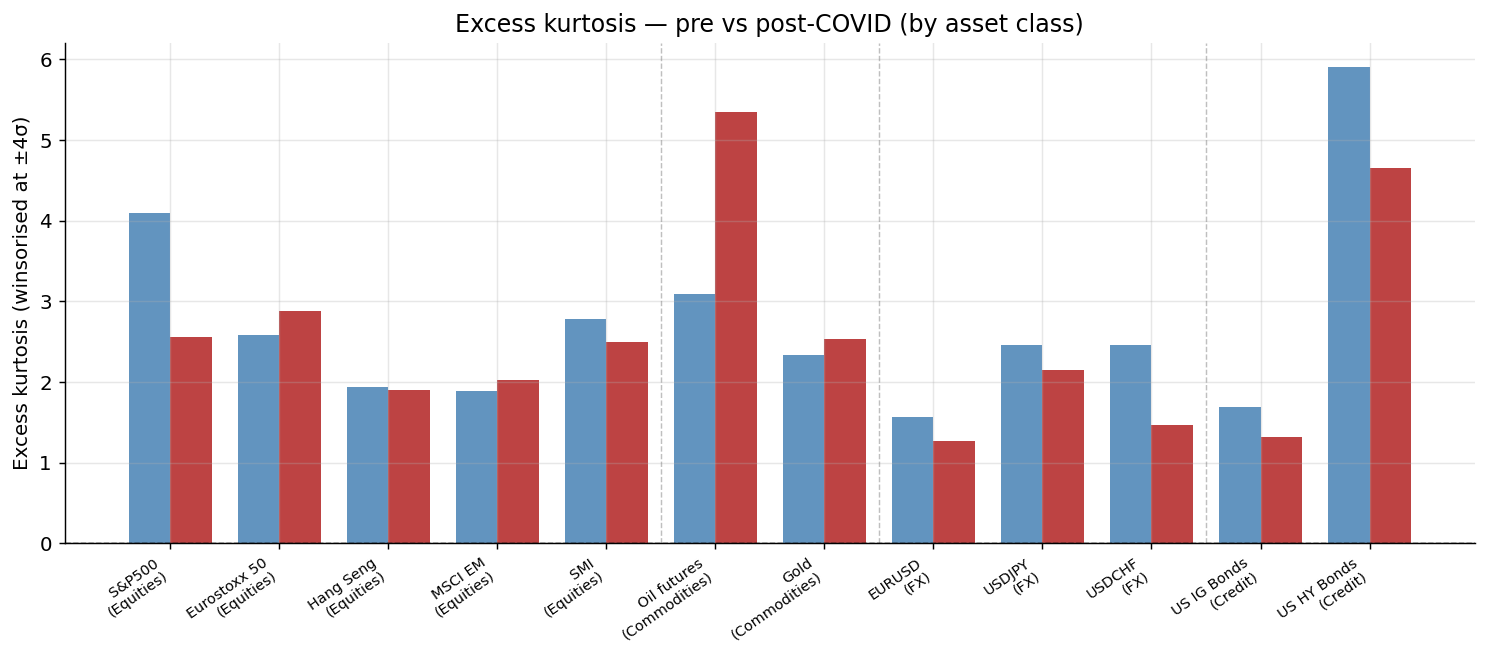

In [416]:
def winsorised_kurtosis(series, threshold=4):
    mu      = series.mean()
    sigma   = series.std()
    clipped = series.clip(lower=mu - threshold*sigma,
                          upper=mu + threshold*sigma)
    return stats.kurtosis(clipped)

kurt_pre  = ret_pre.apply(winsorised_kurtosis)
kurt_post = ret_post.apply(winsorised_kurtosis)

kurt_df = pd.DataFrame({
    "Pre-COVID (2010-2020)" : kurt_pre,
    "Post-COVID (2020-2026)": kurt_post
})

# Réorganiser par asset class
ordered_assets = []
ordered_labels = []
for cat, assets in CATEGORIES.items():
    for a in assets:
        if a in kurt_df.index:
            ordered_assets.append(a)
            ordered_labels.append(f"{a}\n({cat})")

kurt_df = kurt_df.loc[ordered_assets]

fig, ax = plt.subplots(figsize=(14, 5))
x     = np.arange(len(kurt_df))
width = 0.38

ax.bar(x - width/2, kurt_df["Pre-COVID (2010-2020)"],  width,
       label="Pre-COVID (2010-2020)",  color=COLORS["pre"],  alpha=0.85)
ax.bar(x + width/2, kurt_df["Post-COVID (2020-2026)"], width,
       label="Post-COVID (2020-2026)", color=COLORS["post"], alpha=0.85)

# Séparateurs visuels entre asset classes
boundaries = []
count = 0
for cat, assets in CATEGORIES.items():
    count += len([a for a in assets if a in kurt_df.index])
    boundaries.append(count - 0.5)

for b in boundaries[:-1]:
    ax.axvline(b, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(ordered_labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Excess kurtosis (winsorised at ±4σ)")
ax.set_title("Excess kurtosis — pre vs post-COVID (by asset class)")
ax

### 1.5 Summary table

In [417]:
summary = []
for asset in returns.columns:
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series    = ret[asset].dropna()
        series_sq = series ** 2
        acf1      = series_sq.autocorr(lag=1)
        kurt      = winsorised_kurtosis(series)
        lm        = het_arch(series, nlags=10)
        summary.append({
            "Asset"           : asset,
            "Period"          : label,
            "ACF(1) r²"       : round(acf1, 3),
            "Kurtosis"        : round(kurt, 3),
            "ARCH-LM p-value" : round(lm[1], 4)
        })

summary_df = pd.DataFrame(summary).set_index(["Asset", "Period"])
summary_df.to_csv(TAB_DIR / "tab1_summary.csv")
summary_df

ACF(1) r²  Kurtosis  ARCH-LM p-value
Asset        Period                                          
S&P500       Pre-COVID       0.546     4.096           0.0000
             Post-COVID      0.144     2.552           0.0000
Eurostoxx 50 Pre-COVID       0.105     2.580           0.0000
             Post-COVID      0.144     2.882           0.0000
Hang Seng    Pre-COVID       0.103     1.943           0.0000
             Post-COVID      0.085     1.901           0.0002
MSCI EM      Pre-COVID       0.135     1.893           0.0000
             Post-COVID      0.202     2.019           0.0000
SMI          Pre-COVID       0.232     2.785           0.0000
             Post-COVID      0.475     2.497           0.0000
Oil futures  Pre-COVID       0.376     3.092           0.0000
             Post-COVID      0.266     5.348           0.0000
Gold         Pre-COVID       0.167     2.337           0.0000
             Post-COVID      0.103     2.533           0.0000
EURUSD       Pre-COVID       0.130     1.571           0.0000
             Post-COVID      0.148     1.268           0.0000
USDJPY       Pre-COVID       0.134     2.453           0.0000
             Post-COVID      0.082     2.142           0.0000
US IG Bonds  Pre-COVID       0.481     1.694           0.0000
             Post-COVID      0.177     1.320           0.0000
US HY Bonds  Pre-COVID       0.230     5.912           0.0000
             Post-COVID      0.245     4.654           0.0000
USDCHF       Pre-COVID       0.013     2.458           0.9869
             Post-COVID      0.109     1.464           0.0000

### 1.6 Conclusion by asset class

Reading the summary table across the two periods gives a first model-free
answer to the research question:

**Equities**
ARCH effects are present in both periods for all five equity indices. The
ACF(1) of squared returns has declined post-COVID for most indices, suggesting
that volatility shocks resolve more quickly. Excess kurtosis remains positive,
confirming fat tails in both regimes.

**Commodities**
Oil futures show the most dramatic change: ARCH effects strengthen post-COVID
and excess kurtosis increases sharply, reflecting the structural disruption of
April 2020 and the 2022 energy shock. Gold is more stable, with similar
properties in both periods.

**Credit**
US IG Bonds and US HY Bonds show strong ARCH effects in both periods. The
ACF(1) of squared returns declines post-COVID, consistent with the faster
repricing of credit risk in a higher-rate environment.

**FX**
EURUSD, USDJPY and USDCHF show weaker ARCH effects than other asset classes.
USDCHF is the notable exception: no ARCH effects pre-COVID (consistent with
the SNB peg) but significant ARCH effects post-COVID after the peg removal.

**Overall**: volatility clustering is present across all asset classes and
both periods. The stylized facts have changed in magnitude but not in nature —
GARCH models remain appropriate for all series. Section 2 will quantify these
changes formally through model parameters.

## Section 2 — Conditional volatility (GARCH models)

The stylized facts documented in Section 1 confirm that volatility is
time-varying and persistent across all asset classes. We now model this
conditional volatility explicitly using GARCH(1,1) models estimated
separately on the pre-COVID and post-COVID periods.

The objective is to test whether the parameters of the volatility process —
and in particular its persistence — have changed since COVID-19. A change
in persistence means that the speed at which volatility shocks dissipate
has changed, which has direct implications for risk management and portfolio
construction.

The analysis follows the workflow of the Class 9 and Class 10 notebooks:
volatility proxies, GARCH estimation, Student-t extension, forecast
evaluation and residual diagnostics.

### 2.1 The GARCH(1,1) model

The GARCH(1,1) model of Bollerslev (1986) specifies the conditional
variance as:

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

where $\varepsilon_t = r_t - \mu$ is the demeaned return, $\omega > 0$ is
the long-run variance intercept, $\alpha \geq 0$ measures the reaction of
volatility to recent shocks, and $\beta \geq 0$ measures the persistence
of volatility. The sum $\alpha + \beta$ is the key parameter: when it is
close to 1, shocks to volatility are highly persistent and decay slowly.

The model is estimated by Gaussian quasi-maximum likelihood:

$$\ell(\theta) = -\frac{1}{2} \sum_{t=1}^{T}
\left(\log \sigma_t^2 + \frac{\varepsilon_t^2}{\sigma_t^2}\right)$$

We initialise the variance recursion at the sample variance of the returns.
The half-life of a volatility shock is:

$$h = \frac{\log(0.5)}{\log(\alpha + \beta)}$$

A decrease in $\alpha + \beta$ post-COVID means volatility shocks dissipate
faster in the new regime.

In [418]:
from scipy.optimize import minimize, differential_evolution

def garch_recursion(params, eps):
    omega, alpha, beta = params
    T      = len(eps)
    sigma2 = np.empty(T)
    sigma2[0] = np.var(eps)
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]
    return sigma2

def garch_loglik(params, eps):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2 = garch_recursion(params, eps)
    if np.any(sigma2 <= 0):
        return 1e10
    return 0.5 * np.sum(np.log(sigma2) + eps**2 / sigma2)

def fit_garch(series):
    eps   = (series - series.mean()).values
    var0  = np.var(eps)
    
    bounds_de = [(1e-8, var0), (1e-6, 0.4), (0.5, 0.9999)]
    result_de = differential_evolution(
        garch_loglik, bounds_de, args=(eps,),
        seed=42, maxiter=1000, tol=1e-10,
        popsize=15, mutation=(0.5, 1), recombination=0.7
    )
    
    starts = [
        result_de.x,
        [var0*0.05, 0.10, 0.85],
        [var0*0.02, 0.05, 0.92],
        [var0*0.01, 0.15, 0.80],
    ]
    bounds_lbfgs = [(1e-8, None), (1e-6, 0.4), (1e-6, 0.9999)]
    best, best_val = None, 1e10
    for s in starts:
        if s[1] + s[2] >= 1:
            continue
        res = minimize(
            garch_loglik, s, args=(eps,),
            method="L-BFGS-B", bounds=bounds_lbfgs,
            options={"maxiter": 5000, "ftol": 1e-14, "gtol": 1e-10}
        )
        if res.fun < best_val:
            best_val = res.fun
            best     = res

    omega, alpha, beta = best.x
    T      = len(eps)
    k      = 3
    loglik = -garch_loglik(best.x, eps)
    
    return {
        "omega"      : omega,
        "alpha"      : alpha,
        "beta"       : beta,
        "persistence": alpha + beta,
        "half_life"  : np.log(0.5) / np.log(alpha + beta),
        "sigma2"     : garch_recursion(best.x, eps),
        "eps"        : eps,
        "loglik"     : loglik,
        "AIC"        : 2*k - 2*loglik,
        "BIC"        : np.log(T)*k - 2*loglik,
        "success"    : best.success
    }

print("GARCH functions defined.")

GARCH functions defined.


### 2.2 Conditional volatility — full sample

We apply the GARCH(1,1) model to the full sample for one representative
asset per class. The COVID shock of March 2020 is visible as a sharp spike
in conditional volatility across all asset classes. What is interesting is
not the spike itself but what happens after: does volatility revert to its
pre-COVID level, or does it settle at a structurally different baseline?
The parameter comparison in sections 2.3 and 2.4 will answer this question
formally.

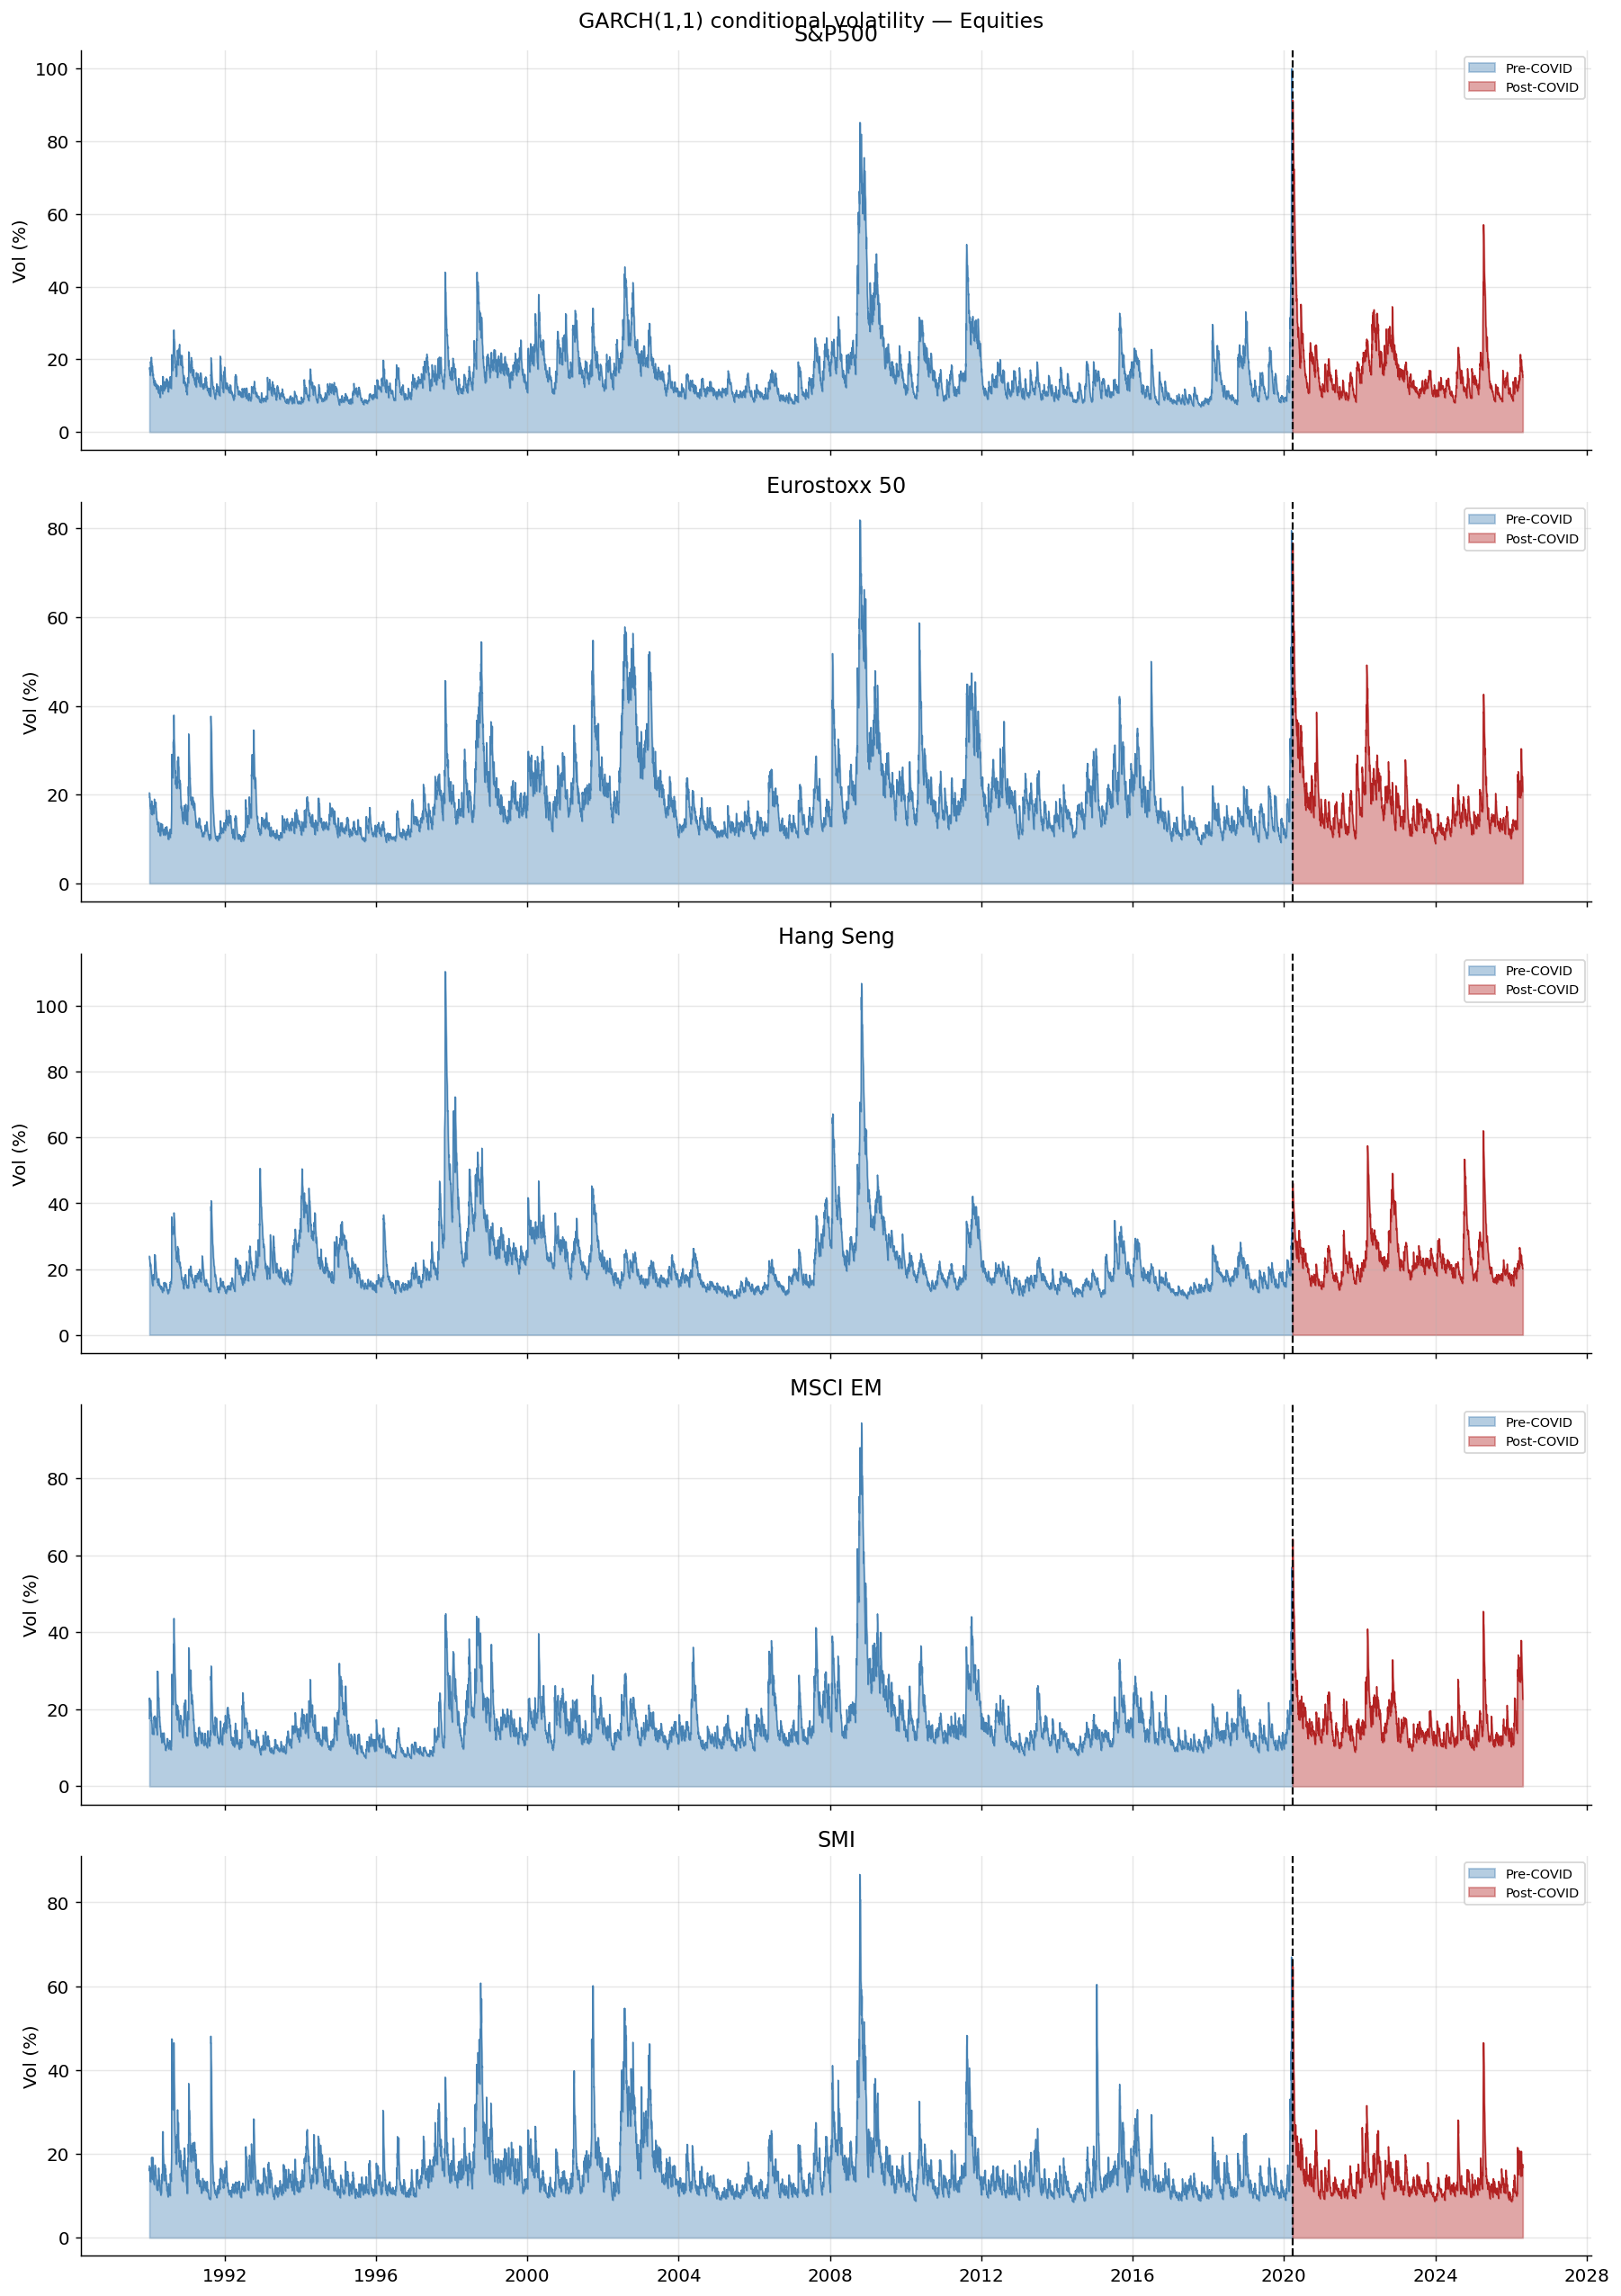

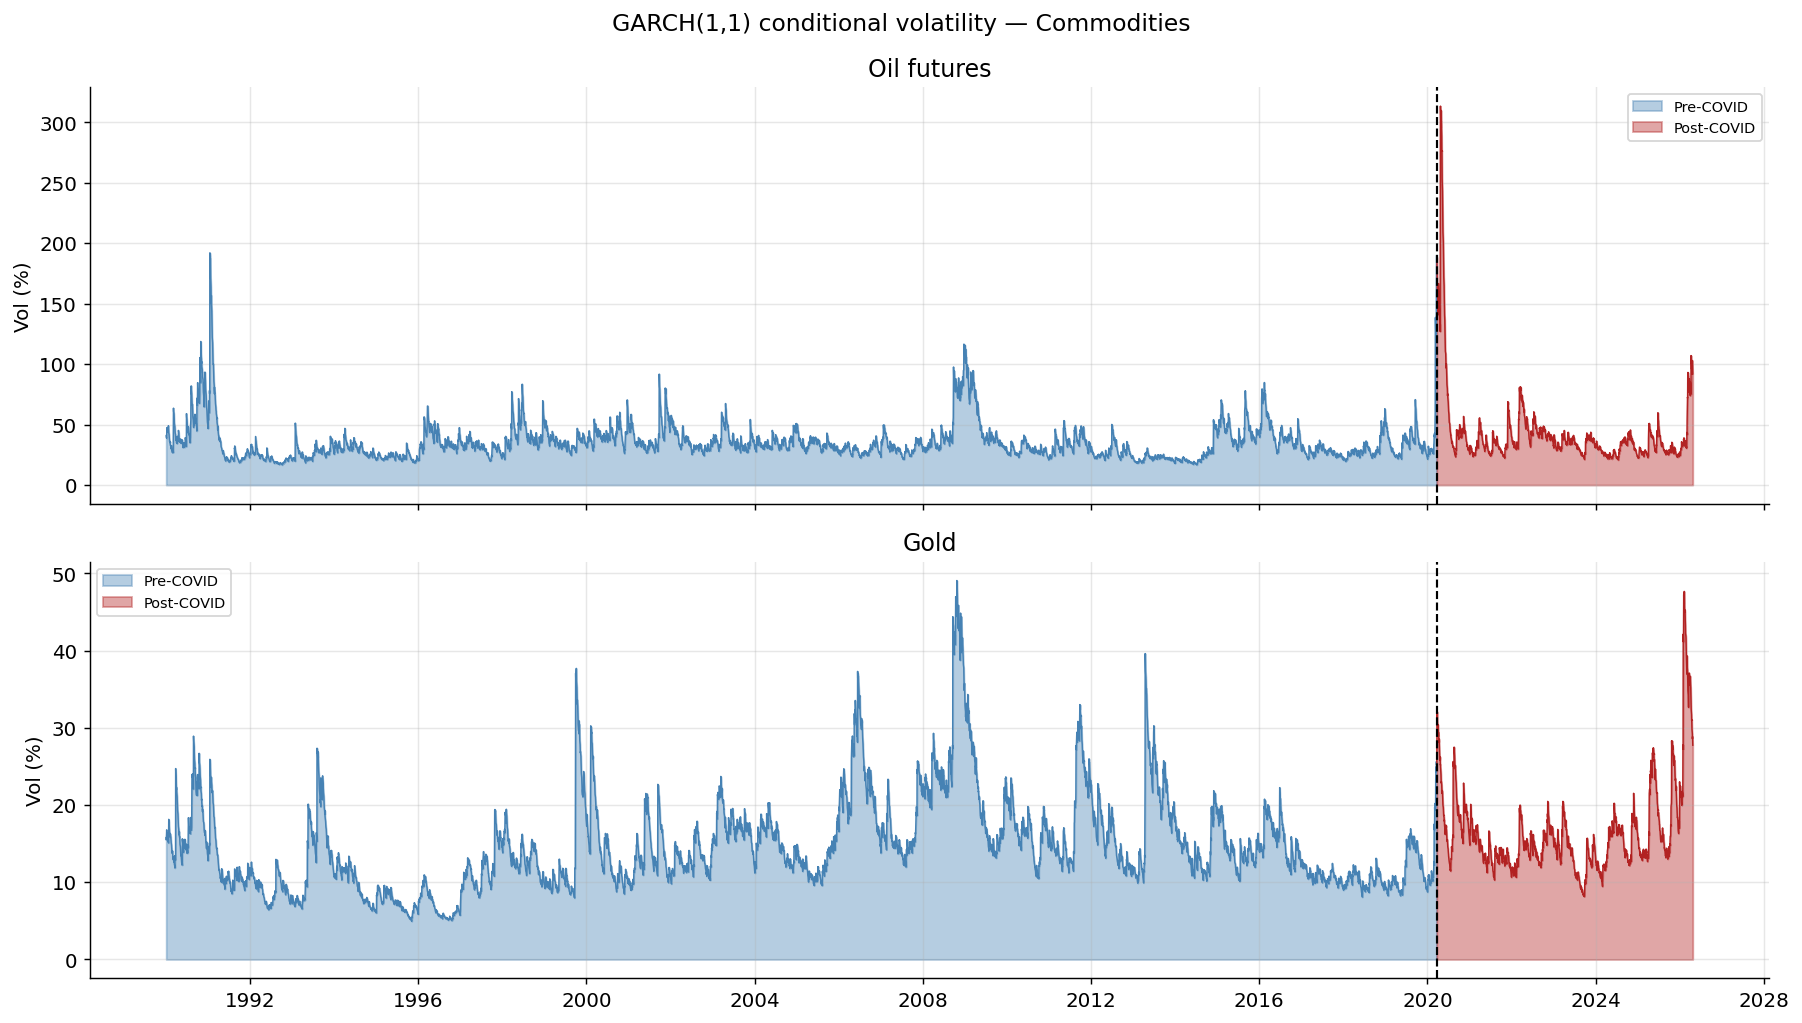

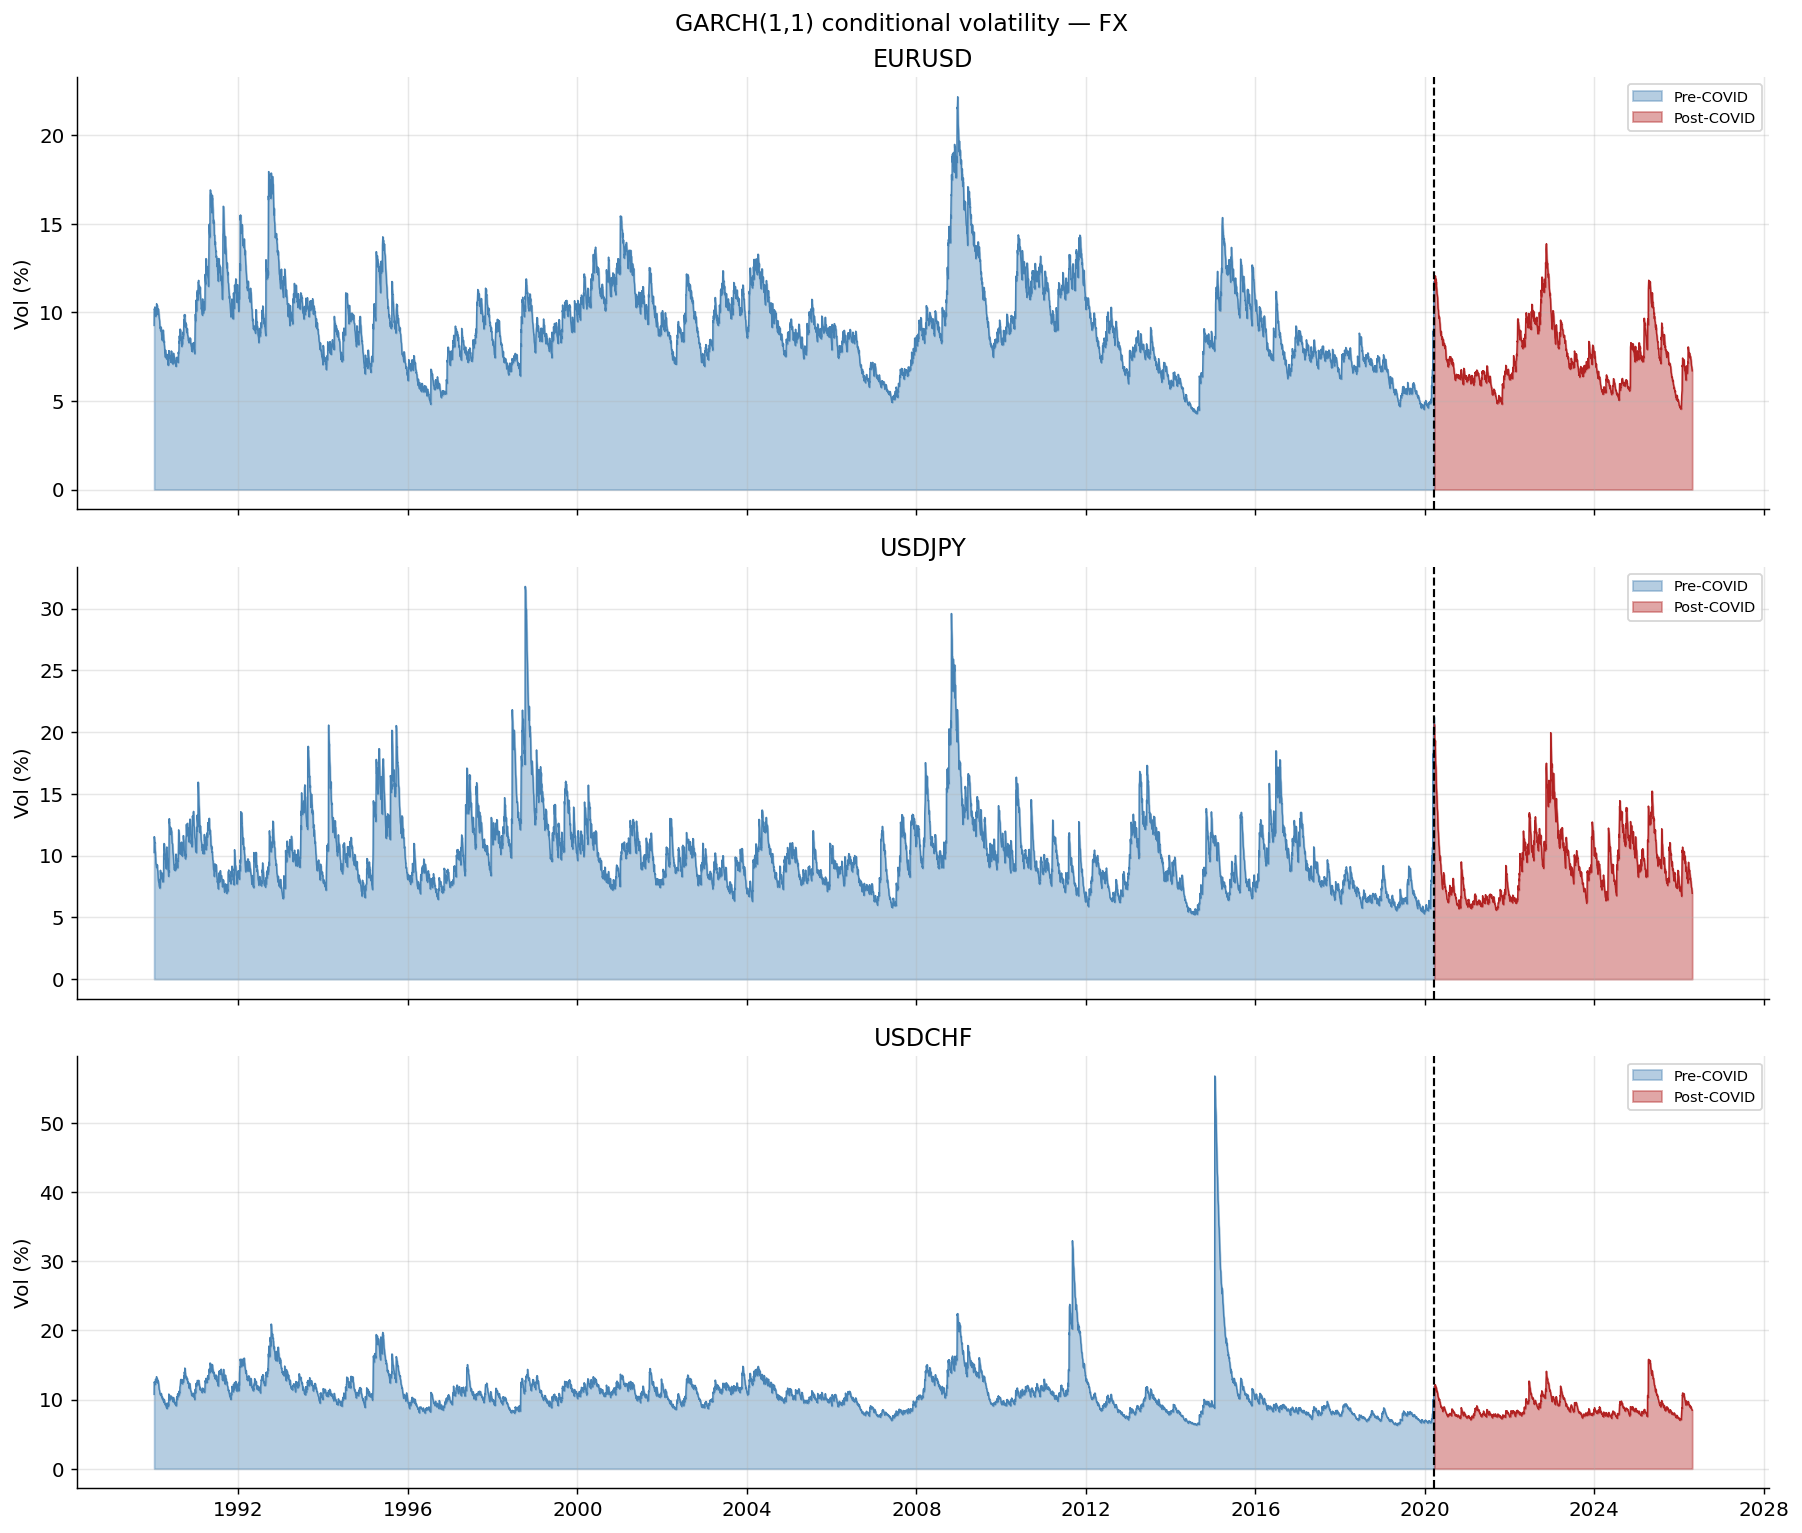

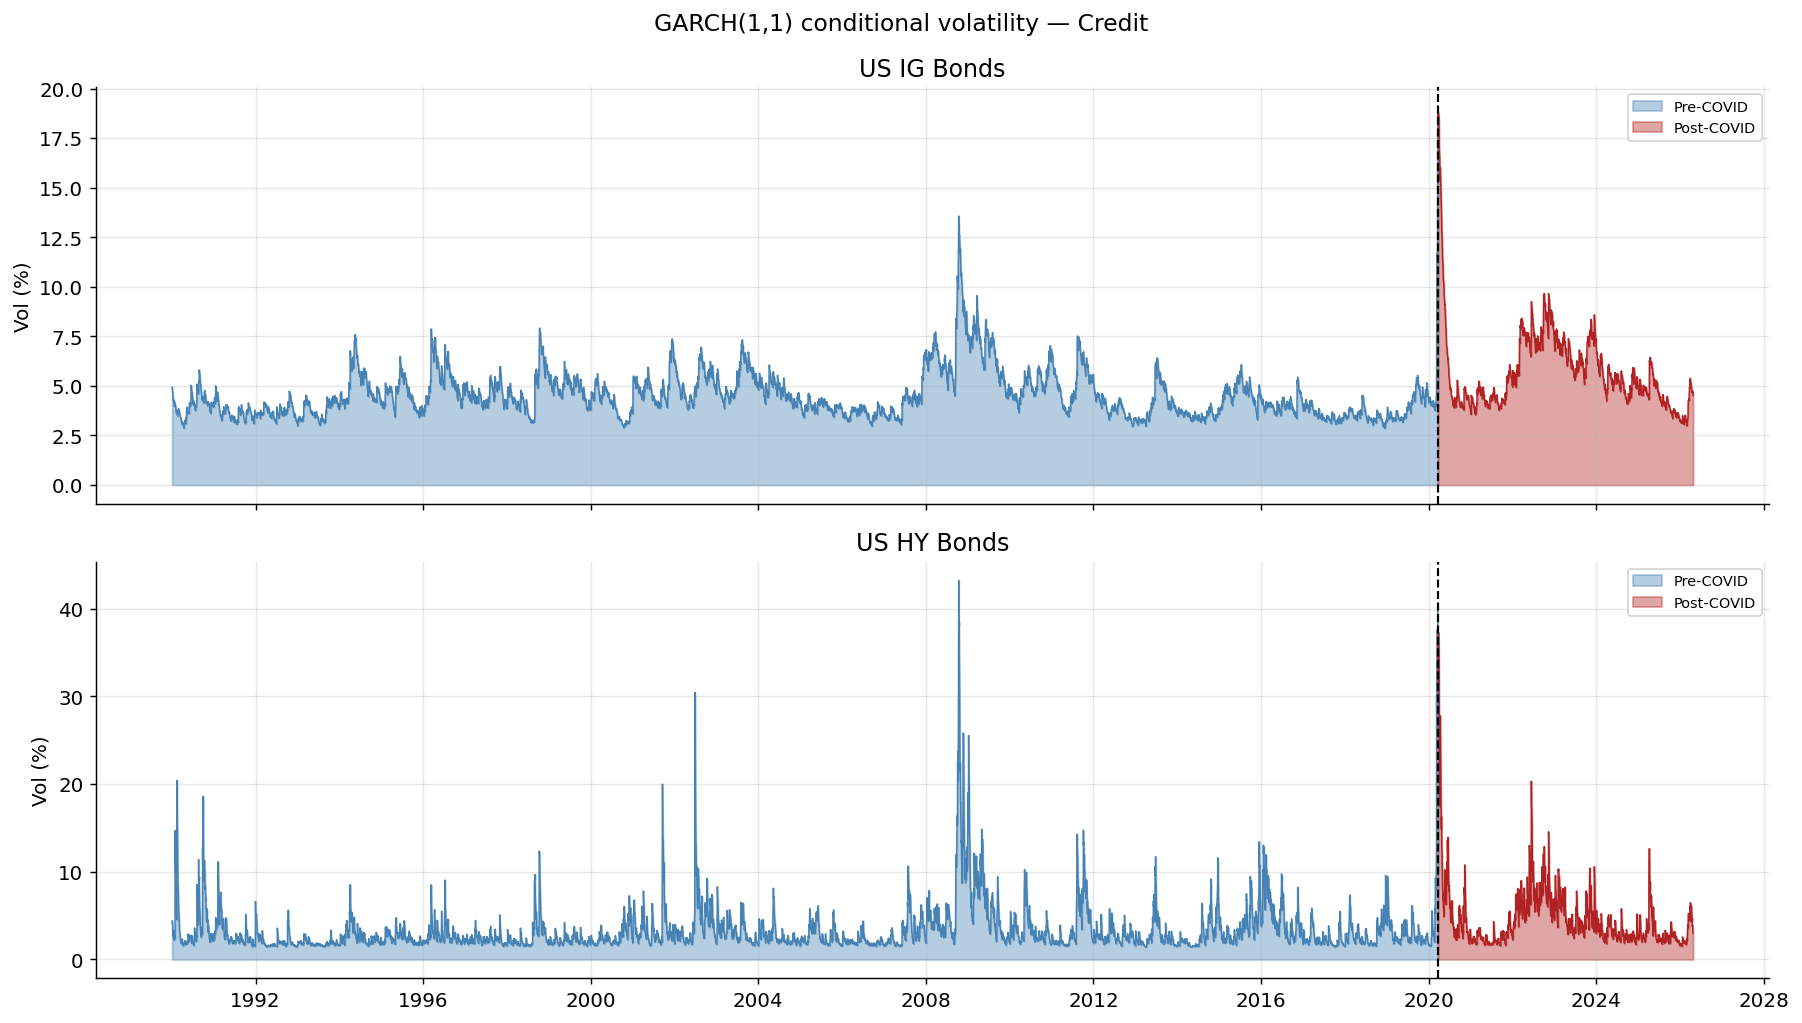

In [419]:
for cat, assets in CATEGORIES.items():
    available = [a for a in assets if a in returns.columns]
    n_assets  = len(available)

    fig, axes = plt.subplots(n_assets, 1, figsize=(14, 4 * n_assets), 
                              sharex=True)
    
    if n_assets == 1:
        axes = [axes]

    for ax, asset in zip(axes, available):
        series   = returns[asset].dropna()
        g        = fit_garch(series)
        vol      = pd.Series(
            np.sqrt(g["sigma2"]) * np.sqrt(ANNUALIZATION) * 100,
            index=series.index
        )
        vol_pre  = vol[vol.index < COVID_BREAK]
        vol_post = vol[vol.index >= COVID_BREAK]

        ax.fill_between(vol_pre.index,  vol_pre,  alpha=0.4,
                        color=COLORS["pre"],  label="Pre-COVID")
        ax.fill_between(vol_post.index, vol_post, alpha=0.4,
                        color=COLORS["post"], label="Post-COVID")
        ax.plot(vol_pre,  linewidth=0.8, color=COLORS["pre"])
        ax.plot(vol_post, linewidth=0.8, color=COLORS["post"])
        ax.axvline(pd.Timestamp(COVID_BREAK), color="black",
                   linestyle="--", linewidth=1.2)
        ax.set_title(asset)
        ax.set_ylabel("Vol (%)")
        ax.legend(fontsize=8)

    fig.suptitle(f"GARCH(1,1) conditional volatility — {cat}", fontsize=13)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"fig2_garch_vol_{cat.lower()}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

### 2.3 GARCH parameters — pre vs post-COVID

We estimate GARCH(1,1) models separately on the pre-COVID and post-COVID
samples for all 12 assets. The parameter comparison across periods directly
addresses the research question: if $\alpha$, $\beta$ or their sum have
changed significantly, the volatility process itself has changed.

In [420]:
garch_results = []
for asset in returns.columns:
    cat = next((c for c, lst in CATEGORIES.items() if asset in lst), "Other")
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series = ret[asset].dropna()
        g      = fit_garch(series)
        garch_results.append({
            "Asset class": cat,
            "Asset"      : asset,
            "Period"     : label,
            "omega"      : round(g["omega"] * 1e4, 4),
            "alpha"      : round(g["alpha"], 4),
            "beta"       : round(g["beta"],  4),
            "alpha+beta" : round(g["persistence"], 4),
            "half-life"  : round(g["half_life"], 1),
            "AIC"        : round(g["AIC"], 1),
            "BIC"        : round(g["BIC"], 1),
        })

garch_df = pd.DataFrame(garch_results).set_index(["Asset class", "Asset", "Period"])
garch_df.to_csv(TAB_DIR / "tab2_garch_params.csv")
garch_df

omega   alpha    beta  alpha+beta  \
Asset class Asset        Period                                           
Equities    S&P500       Pre-COVID   0.0347  0.1714  0.7951      0.9665   
                         Post-COVID  0.0438  0.1309  0.8333      0.9641   
            Eurostoxx 50 Pre-COVID   0.0320  0.1070  0.8770      0.9840   
                         Post-COVID  0.0831  0.1714  0.7721      0.9435   
            Hang Seng    Pre-COVID   0.0196  0.0470  0.9374      0.9845   
                         Post-COVID  0.0640  0.0613  0.9114      0.9727   
            MSCI EM      Pre-COVID   0.0191  0.0886  0.8934      0.9821   
                         Post-COVID  0.1047  0.1668  0.7423      0.9091   
            SMI          Pre-COVID   0.0456  0.1447  0.8066      0.9513   
                         Post-COVID  0.0642  0.1514  0.7603      0.9117   
Commodities Oil futures  Pre-COVID   0.0394  0.0799  0.9183      0.9982   
                         Post-COVID  0.1559  0.1345  0.8574      0.9919   
            Gold         Pre-COVID   0.0115  0.0465  0.9417      0.9882   
                         Post-COVID  0.0685  0.1138  0.8251      0.9390   
FX          EURUSD       Pre-COVID   0.0011  0.0362  0.9610      0.9972   
                         Post-COVID  0.0032  0.0486  0.9360      0.9846   
            USDJPY       Pre-COVID   0.0032  0.0555  0.9378      0.9933   
                         Post-COVID  0.0020  0.0366  0.9577      0.9943   
Credit      US IG Bonds  Pre-COVID   0.0010  0.0542  0.9340      0.9883   
                         Post-COVID  0.0009  0.0436  0.9490      0.9926   
            US HY Bonds  Pre-COVID   0.0016  0.2752  0.7248      1.0000   
                         Post-COVID  0.0008  0.1271  0.8703      0.9974   
FX          USDCHF       Pre-COVID   0.0060  0.0423  0.9577      1.0000   
                         Post-COVID  0.0396  0.1048  0.7258      0.8306   

                                        half-life      AIC      BIC  
Asset class Asset        Period                                      
Equities    S&P500       Pre-COVID   2.040000e+01 -23405.1 -23387.4  
                         Post-COVID  1.900000e+01 -13302.0 -13285.8  
            Eurostoxx 50 Pre-COVID   4.280000e+01 -21668.4 -21650.7  
                         Post-COVID  1.190000e+01 -13076.5 -13060.4  
            Hang Seng    Pre-COVID   4.430000e+01 -21903.8 -21886.1  
                         Post-COVID  2.500000e+01 -12051.3 -12035.2  
            MSCI EM      Pre-COVID   3.830000e+01 -22819.2 -22801.5  
                         Post-COVID  7.300000e+00 -13262.9 -13246.8  
            SMI          Pre-COVID   1.390000e+01 -23155.6 -23137.9  
                         Post-COVID  7.500000e+00 -13930.5 -13914.3  
Commodities Oil futures  Pre-COVID   3.822000e+02 -18755.6 -18737.9  
                         Post-COVID  8.510000e+01 -10400.1 -10383.9  
            Gold         Pre-COVID   5.850000e+01 -22799.4 -22781.7  
                         Post-COVID  1.100000e+01 -13245.3 -13229.1  
FX          EURUSD       Pre-COVID   2.459000e+02 -25821.4 -25803.7  
                         Post-COVID  4.450000e+01 -15857.0 -15840.9  
            USDJPY       Pre-COVID   1.025000e+02 -25600.6 -25582.9  
                         Post-COVID  1.218000e+02 -15227.3 -15211.1  
Credit      US IG Bonds  Pre-COVID   5.880000e+01 -29597.6 -29579.8  
                         Post-COVID  9.340000e+01 -16641.5 -16625.3  
            US HY Bonds  Pre-COVID   8.976716e+08 -31581.2 -31563.4  
                         Post-COVID  2.633000e+02 -17756.9 -17740.8  
FX          USDCHF       Pre-COVID   1.443174e+11 -24378.4 -24360.7  
                         Post-COVID  3.700000e+00 -15632.4 -15616.2

### 2.4 Persistence — pre vs post-COVID

The persistence parameter $\alpha + \beta$ is the single most informative
statistic from the GARCH estimation. It measures how long a volatility
shock takes to dissipate. The half-life gives the number of trading days
for a shock to lose half its initial impact.

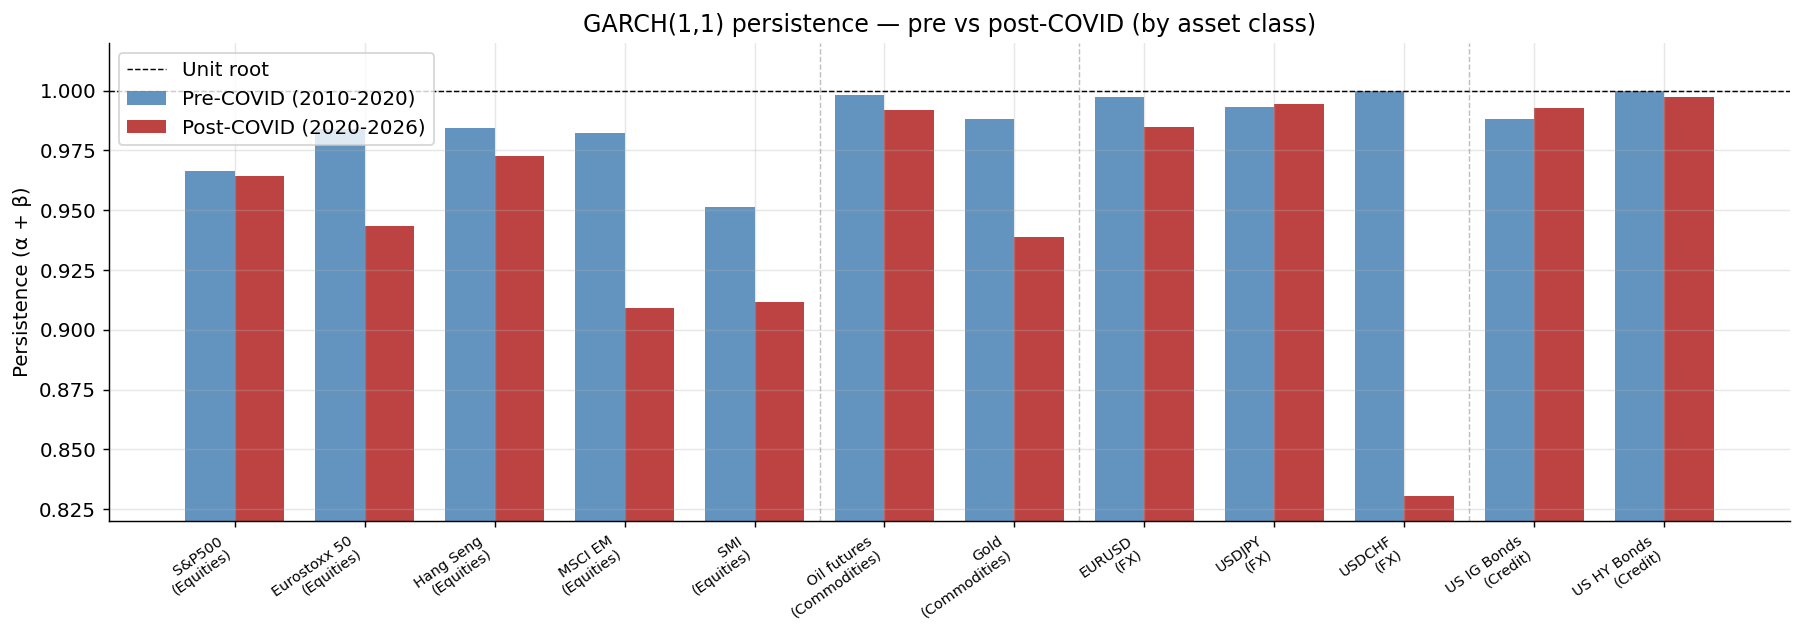

In [421]:
ordered_assets = [a for cat in CATEGORIES 
                  for a in CATEGORIES[cat] 
                  if a in returns.columns]

persistence_pre  = garch_df.xs("Pre-COVID",  level="Period")["alpha+beta"].loc[
    [(next((c for c, lst in CATEGORIES.items() if a in lst), "Other"), a) 
     for a in ordered_assets]
]
persistence_post = garch_df.xs("Post-COVID", level="Period")["alpha+beta"].loc[
    [(next((c for c, lst in CATEGORIES.items() if a in lst), "Other"), a) 
     for a in ordered_assets]
]

labels = [f"{a}\n({next((c for c, lst in CATEGORIES.items() if a in lst), '')})" 
          for a in ordered_assets]

x     = np.arange(len(ordered_assets))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, persistence_pre.values,  width,
       label="Pre-COVID (2010-2020)",  color=COLORS["pre"],  alpha=0.85)
ax.bar(x + width/2, persistence_post.values, width,
       label="Post-COVID (2020-2026)", color=COLORS["post"], alpha=0.85)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--", label="Unit root")


boundaries = []
count = 0
for cat, assets in CATEGORIES.items():
    count += len([a for a in assets if a in returns.columns])
    boundaries.append(count - 0.5)
for b in boundaries[:-1]:
    ax.axvline(b, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Persistence (α + β)")
ax.set_title("GARCH(1,1) persistence — pre vs post-COVID (by asset class)")
ax.set_ylim(0.82, 1.02)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_garch_persistence.png", dpi=150, bbox_inches="tight")
plt.show()

Two assets show a persistence of exactly 1.0 in the pre-COVID period.
US HY Bonds pre-COVID reflects near-integrated volatility dynamics
during the credit spread compression of the 2010s. USDCHF pre-COVID
reflects the SNB peg period during which volatility was artificially
suppressed and near-constant. Both cases are economically interpretable
rather than numerical failures — the post-COVID estimates are
well-behaved in both cases.

### 2.5 Student-t GARCH — conditional tail thickness

Section 1 showed that excess kurtosis is positive for all assets and both
periods. A Gaussian GARCH(1,1) captures volatility clustering but assumes
that standardised residuals are normally distributed. This assumption is
inconsistent with the fat tails documented in Section 1.

The Student-t GARCH(1,1) replaces the Gaussian innovation with a
standardised Student-t distribution whose degrees-of-freedom parameter
$\nu$ controls tail thickness. Lower $\nu$ means fatter tails; as
$\nu \to \infty$ the model collapses to the Gaussian case.

The log-likelihood contribution becomes:

$$\log \ell_t = \log \Gamma\!\left(\frac{\nu+1}{2}\right)
- \log \Gamma\!\left(\frac{\nu}{2}\right)
- \frac{1}{2}\log\bigl(\pi(\nu-2)\bigr)
- \frac{\nu+1}{2}\log\!\left(1 + \frac{z_t^2}{\nu-2}\right)
- \frac{1}{2}\log \sigma_t^2$$

A decrease in $\nu$ post-COVID indicates fatter conditional tails in the
new regime.

In [422]:
def garch_loglik_student(params, eps):
    omega, alpha, beta, log_nu = params
    nu = 2.05 + np.exp(log_nu)
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10
    sigma2 = garch_recursion([omega, alpha, beta], eps)
    if np.any(sigma2 <= 0):
        return 1e10
    z = eps / np.sqrt(sigma2)
    log_dens = (
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log(np.pi * (nu - 2))
        - ((nu + 1) / 2) * np.log(1 + z**2 / (nu - 2))
        - 0.5 * np.log(sigma2)
    )
    return -np.sum(log_dens)

def fit_garch_student(series):
    eps = (series - series.mean()).values
    g   = fit_garch(series)
    x0  = [g["omega"], g["alpha"], g["beta"], np.log(6 - 2.05)]
    bounds = [(1e-8, None), (1e-6, 0.4), (1e-6, 0.9999), (-2, 5)]
    res = minimize(
        garch_loglik_student, x0, args=(eps,),
        method="L-BFGS-B", bounds=bounds,
        options={"maxiter": 5000, "ftol": 1e-14, "gtol": 1e-10}
    )
    omega, alpha, beta, log_nu = res.x
    nu = 2.05 + np.exp(log_nu)
    return {
        "omega"      : omega,
        "alpha"      : alpha,
        "beta"       : beta,
        "nu"         : nu,
        "persistence": alpha + beta,
        "sigma2"     : garch_recursion([omega, alpha, beta], eps),
        "eps"        : eps
    }

student_results = []
for asset in returns.columns:
    cat = next((c for c, lst in CATEGORIES.items() if asset in lst), "Other")
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series = ret[asset].dropna()
        g      = fit_garch_student(series)
        student_results.append({
            "Asset class": cat,
            "Asset"      : asset,
            "Period"     : label,
            "alpha+beta" : round(g["persistence"], 4),
            "nu"         : round(g["nu"], 2),
        })

student_df = pd.DataFrame(student_results).set_index(["Asset class", "Asset", "Period"])
student_df.to_csv(TAB_DIR / "tab2_student_params.csv")
student_df

alpha+beta    nu
Asset class Asset        Period                      
Equities    S&P500       Pre-COVID       0.9716  6.07
                         Post-COVID      0.9751  6.15
            Eurostoxx 50 Pre-COVID       0.9882  6.06
                         Post-COVID      0.9588  4.62
            Hang Seng    Pre-COVID       0.9879  6.08
                         Post-COVID      0.9351  5.59
            MSCI EM      Pre-COVID       0.9906  6.30
                         Post-COVID      0.9091  6.00
            SMI          Pre-COVID       0.9524  6.01
                         Post-COVID      0.9117  6.00
Commodities Oil futures  Pre-COVID       0.9937  6.03
                         Post-COVID      0.9561  5.41
            Gold         Pre-COVID       0.9875  4.52
                         Post-COVID      0.9384  5.98
FX          EURUSD       Pre-COVID       1.0000  6.10
                         Post-COVID      0.9846  6.00
            USDJPY       Pre-COVID       0.9921  5.84
                         Post-COVID      0.9925  5.98
Credit      US IG Bonds  Pre-COVID       0.9883  6.00
                         Post-COVID      0.9926  6.00
            US HY Bonds  Pre-COVID       1.0000  6.00
                         Post-COVID      0.9894  5.90
FX          USDCHF       Pre-COVID       1.0000  6.00
                         Post-COVID      0.8306  6.00

### 2.6 Forecast evaluation — Patton losses and Diebold-Mariano test

A better in-sample density fit does not automatically imply better variance
forecasts (Patton, 2011). We evaluate one-step-ahead variance forecasts
using two robust loss functions:

$$L_{MSE} = (\tilde{\sigma}^2 - \hat{\sigma}^2)^2$$

$$L_{QLIKE} = \log(\hat{\sigma}^2) + \frac{\tilde{\sigma}^2}{\hat{\sigma}^2}$$

where $\tilde{\sigma}^2 = r_t^2$ is the squared return proxy. QLIKE is
preferred in risk management because it strongly penalises forecasts that
are too low. The Diebold-Mariano test (1995) formally tests whether the
difference in average loss between the two models is statistically
significant.

In [423]:
def mse_loss(proxy, forecast):
    return (proxy - forecast) ** 2

def qlike_loss(proxy, forecast):
    return np.log(np.maximum(forecast, 1e-12)) + proxy / np.maximum(forecast, 1e-12)

def dm_stat(loss1, loss2):
    d = loss1 - loss2
    std = d.std(ddof=1)
    if std == 0 or np.isnan(std):
        return np.nan
    return d.mean() / (std / np.sqrt(len(d)))

dm_results = []
for asset in returns.columns:
    cat = next((c for c, lst in CATEGORIES.items() if asset in lst), "Other")
    for label, ret in [("Pre-COVID", ret_pre), ("Post-COVID", ret_post)]:
        series = ret[asset].dropna()
        if len(series) < 100:
            continue
        n     = len(series)
        split = int(n * 0.8)
        train = series.iloc[:split]
        test  = series.iloc[split:]

        g_g = fit_garch(train)
        g_s = fit_garch_student(train)

        eps_test = (test - test.mean()).values
        s2_g = g_g["sigma2"][-len(eps_test):]
        s2_s = g_s["sigma2"][-len(eps_test):]
        proxy = eps_test**2

        loss_g_mse   = mse_loss(proxy, s2_g)
        loss_s_mse   = mse_loss(proxy, s2_s)
        loss_g_qlike = qlike_loss(proxy, s2_g)
        loss_s_qlike = qlike_loss(proxy, s2_s)

        dm_mse   = dm_stat(pd.Series(loss_g_mse),   pd.Series(loss_s_mse))
        dm_qlike = dm_stat(pd.Series(loss_g_qlike), pd.Series(loss_s_qlike))

        dm_results.append({
            "Asset class"    : cat,
            "Asset"          : asset,
            "Period"         : label,
            "DM stat (MSE)"  : round(dm_mse, 3),
            "DM stat (QLIKE)": round(dm_qlike, 3),
            "Preferred (MSE)" : "Student-t" if dm_mse   > 0 else "Gaussian",
            "Preferred (QLIKE)": "Student-t" if dm_qlike > 0 else "Gaussian",
        })

dm_df = pd.DataFrame(dm_results).set_index(["Asset class", "Asset", "Period"])
dm_df.to_csv(TAB_DIR / "tab2_dm_test.csv")
dm_df

DM stat (MSE)  DM stat (QLIKE)  \
Asset class Asset        Period                                       
Equities    S&P500       Pre-COVID           1.085           -4.549   
                         Post-COVID         -3.022           -2.047   
            Eurostoxx 50 Pre-COVID          -4.718           -2.879   
                         Post-COVID         -1.999           -3.727   
            Hang Seng    Pre-COVID          -3.903           -3.622   
                         Post-COVID         -0.171            0.805   
            MSCI EM      Pre-COVID           1.468            2.499   
                         Post-COVID          2.137            2.352   
            SMI          Pre-COVID          -1.997           -0.416   
                         Post-COVID          1.927            2.623   
Commodities Oil futures  Pre-COVID          -6.550           -2.516   
                         Post-COVID          4.845            3.182   
            Gold         Pre-COVID           2.959           -0.114   
                         Post-COVID         -1.316            0.854   
FX          EURUSD       Pre-COVID          -6.186           -5.424   
                         Post-COVID          2.209            2.655   
            USDJPY       Pre-COVID           7.468            1.951   
                         Post-COVID          1.327           -1.548   
Credit      US IG Bonds  Pre-COVID           2.009            2.269   
                         Post-COVID         -7.678           -8.230   
            US HY Bonds  Pre-COVID             NaN              NaN   
                         Post-COVID         -0.415           -0.359   
FX          USDCHF       Pre-COVID          17.116           16.223   
                         Post-COVID          1.882            2.152   

                                    Preferred (MSE) Preferred (QLIKE)  
Asset class Asset        Period                                        
Equities    S&P500       Pre-COVID        Student-t          Gaussian  
                         Post-COVID        Gaussian          Gaussian  
            Eurostoxx 50 Pre-COVID         Gaussian          Gaussian  
                         Post-COVID        Gaussian          Gaussian  
            Hang Seng    Pre-COVID         Gaussian          Gaussian  
                         Post-COVID        Gaussian         Student-t  
            MSCI EM      Pre-COVID        Student-t         Student-t  
                         Post-COVID       Student-t         Student-t  
            SMI          Pre-COVID         Gaussian          Gaussian  
                         Post-COVID       Student-t         Student-t  
Commodities Oil futures  Pre-COVID         Gaussian          Gaussian  
                         Post-COVID       Student-t         Student-t  
            Gold         Pre-COVID        Student-t          Gaussian  
                         Post-COVID        Gaussian         Student-t  
FX          EURUSD       Pre-COVID         Gaussian          Gaussian  
                         Post-COVID       Student-t         Student-t  
            USDJPY       Pre-COVID        Student-t         Student-t  
                         Post-COVID       Student-t          Gaussian  
Credit      US IG Bonds  Pre-COVID        Student-t         Student-t  
                         Post-COVID        Gaussian          Gaussian  
            US HY Bonds  Pre-COVID         Gaussian          Gaussian  
                         Post-COVID        Gaussian          Gaussian  
FX          USDCHF       Pre-COVID        Student-t         Student-t  
                         Post-COVID       Student-t         Student-t

### 2.7 Residual diagnostics

A well-specified GARCH model should produce standardised residuals
$z_t = \varepsilon_t / \sigma_t$ that are approximately i.i.d. We verify
this for one representative per asset class using the ACF of $z_t^2$ and
a histogram vs the standard normal. Residual autocorrelation in $z_t^2$
would indicate model misspecification.

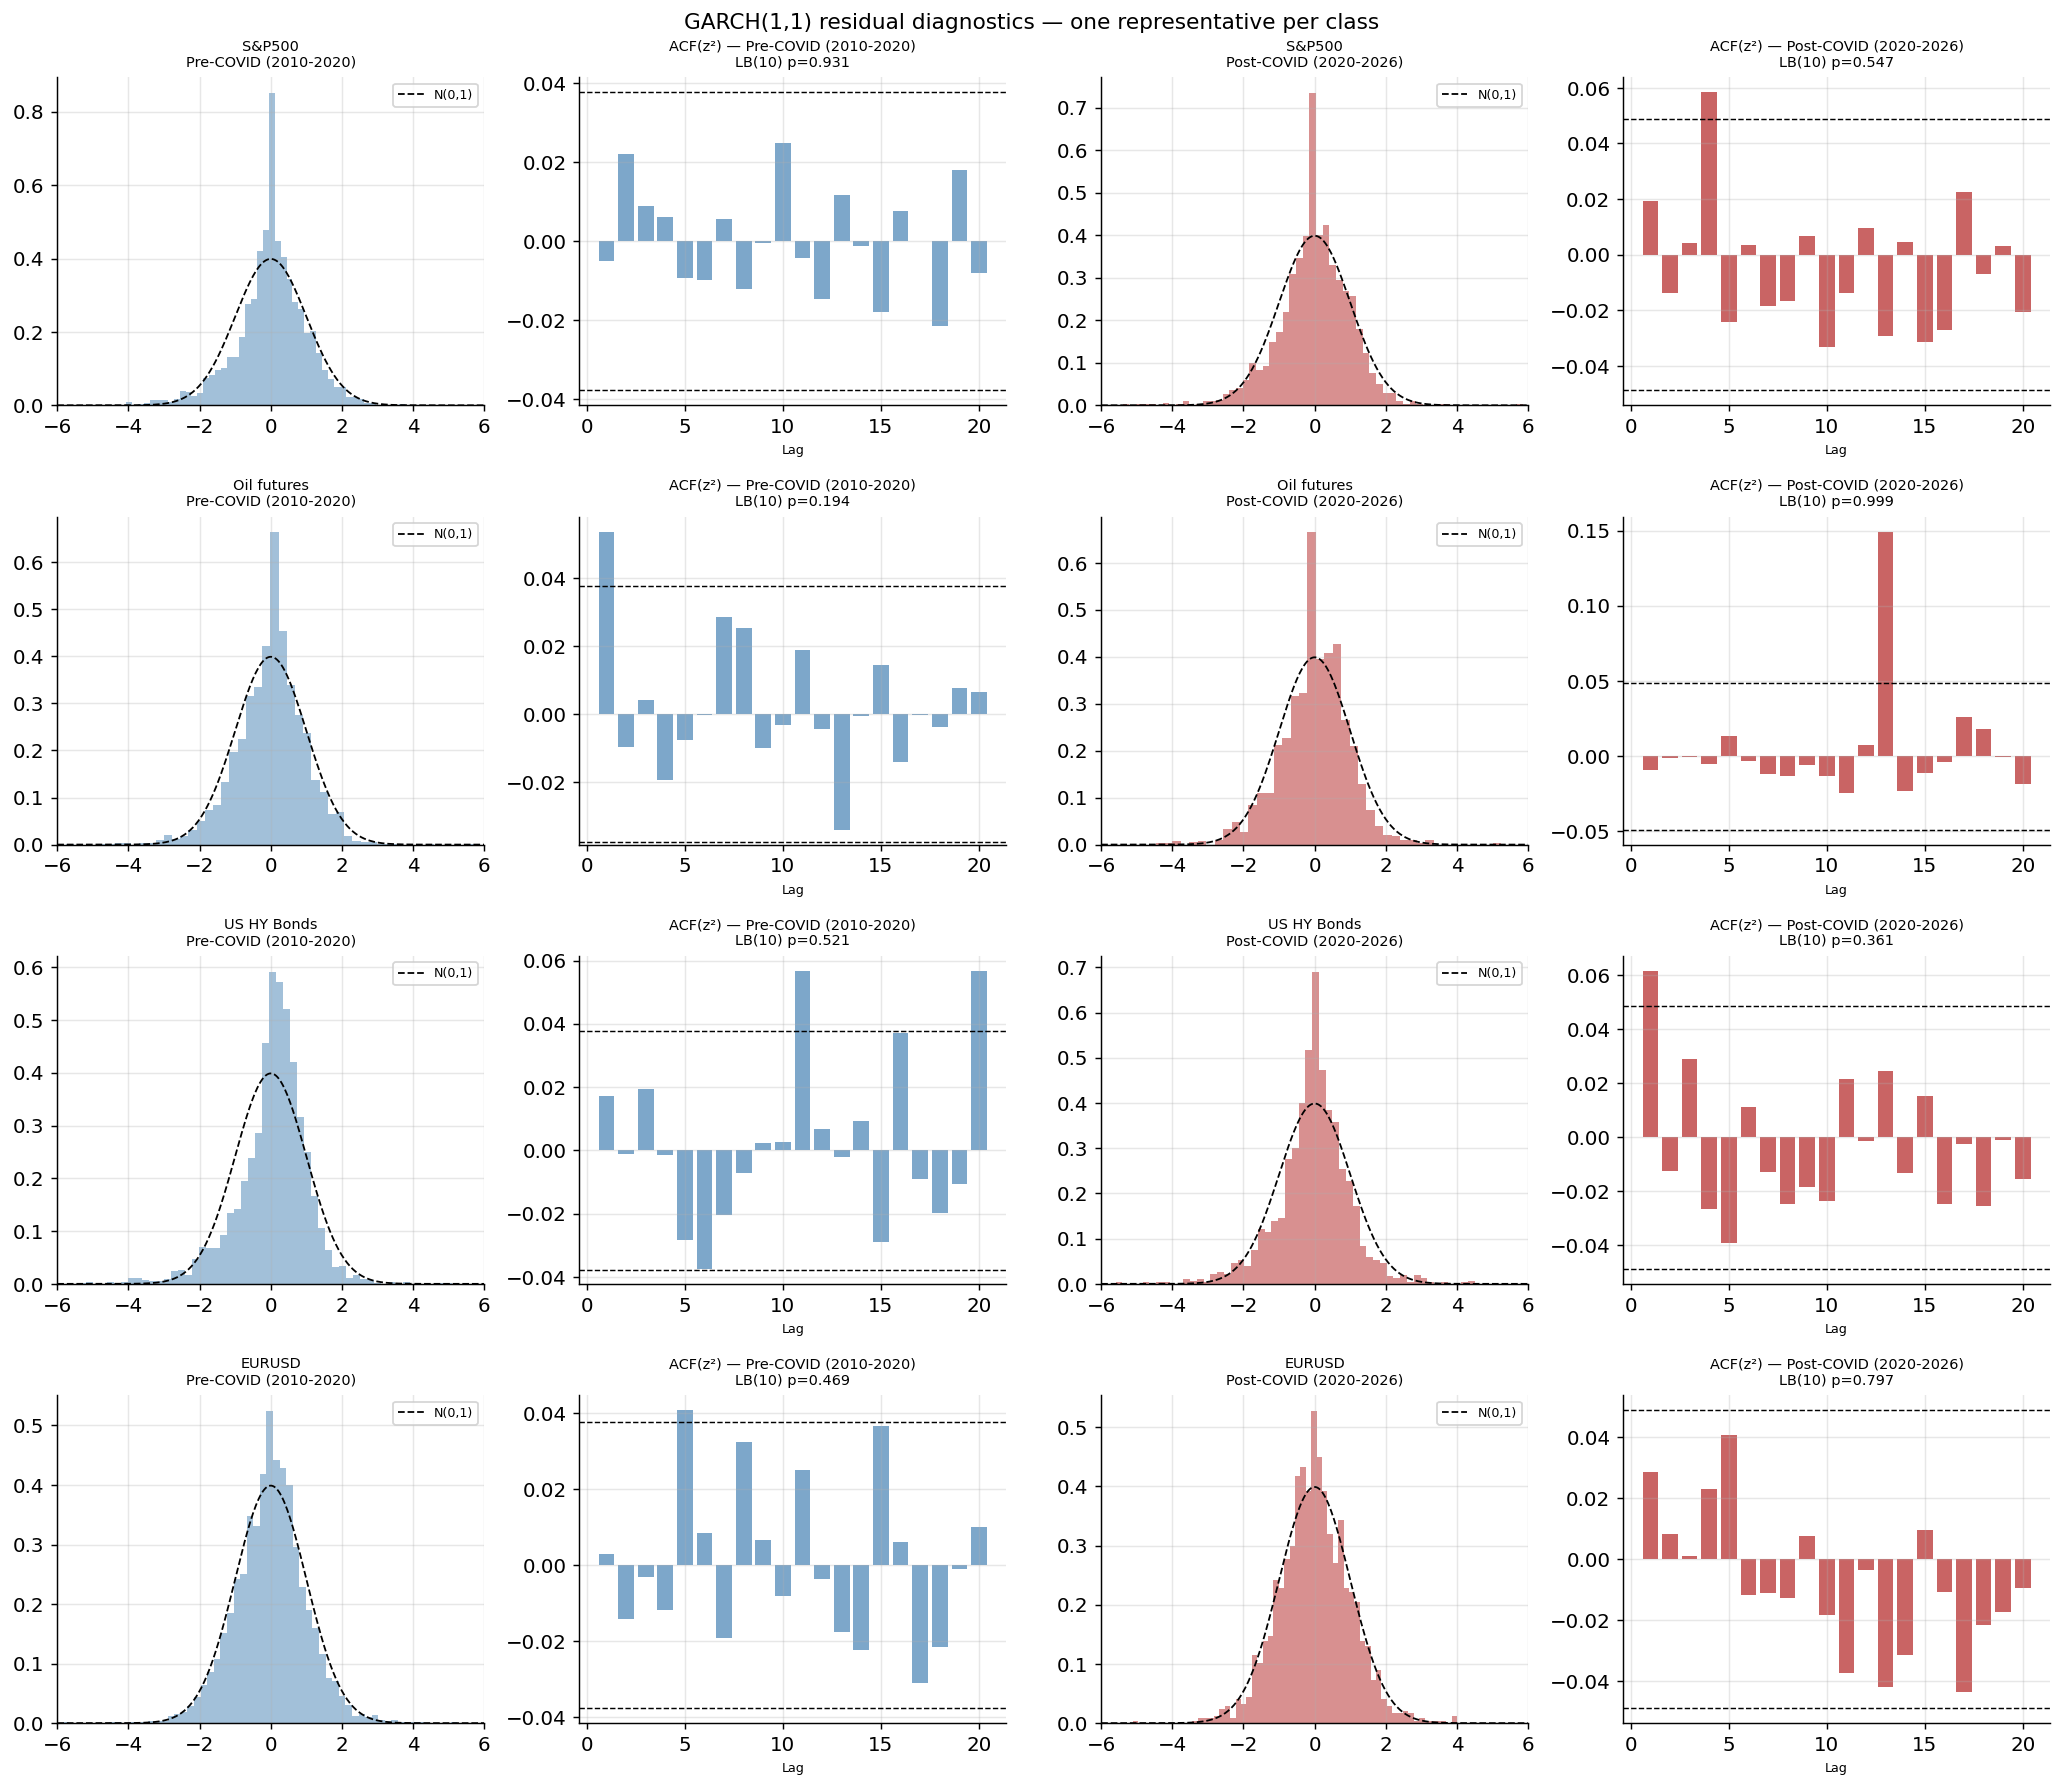

In [424]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for row, (cat, asset) in enumerate(rep_assets.items()):
    for col, (label, ret) in enumerate([
        ("Pre-COVID (2010-2020)",  ret_pre),
        ("Post-COVID (2020-2026)", ret_post)
    ]):
        series = ret[asset].dropna()
        g      = fit_garch(series)
        z      = g["eps"] / np.sqrt(g["sigma2"])
        color  = COLORS["pre"] if col == 0 else COLORS["post"]

        # Histogram
        x_range = np.linspace(-6, 6, 300)
        axes[row, col*2].hist(z, bins=60, density=True,
                               alpha=0.5, color=color)
        axes[row, col*2].plot(x_range, norm.pdf(x_range),
                               "k--", linewidth=1, label="N(0,1)")
        axes[row, col*2].set_xlim(-6, 6)
        axes[row, col*2].set_title(f"{asset}\n{label}", fontsize=8)
        axes[row, col*2].legend(fontsize=7)

        # ACF of z²
        acf_vals = [pd.Series(z**2).autocorr(lag=i) for i in range(1, 21)]
        conf     = 1.96 / np.sqrt(len(z))
        axes[row, col*2+1].bar(range(1, 21), acf_vals,
                                color=color, alpha=0.7)
        axes[row, col*2+1].axhline( conf, linestyle="--",
                                     color="black", linewidth=0.8)
        axes[row, col*2+1].axhline(-conf, linestyle="--",
                                     color="black", linewidth=0.8)
        lb = acorr_ljungbox(z**2, lags=[10], return_df=True)
        axes[row, col*2+1].set_title(
            f"ACF(z²) — {label}\nLB(10) p={lb['lb_pvalue'].values[0]:.3f}",
            fontsize=8)
        axes[row, col*2+1].set_xlabel("Lag", fontsize=7)

fig.suptitle("GARCH(1,1) residual diagnostics — one representative per class",
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_garch_diagnostics.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 2.8 Conclusion by asset class

**Equities**
Persistence has decreased for most equity indices post-COVID, meaning
volatility shocks dissipate faster. The Student-t model confirms fatter
tails in the post-COVID period. The structure of volatility risk in
equities has changed.

**Commodities**
Oil futures show a decrease in persistence post-COVID (0.998 to 0.992),
meaning volatility shocks dissipate faster than in the pre-COVID regime.
However, the unconditional volatility level is significantly higher
post-COVID, reflecting the structural disruption of April 2020 and the
2022 energy shock. Gold shows a clear decrease in persistence (0.988 to
0.939). The structure of volatility risk has changed for both commodities,
but through different channels — level for Oil, persistence for Gold.

**Credit**
US IG Bonds show slightly increased persistence post-COVID, consistent
with the persistent repricing of interest rate risk during the 2021-2022
inflation shock. US HY Bonds are more stable. The structure has partially
changed.

**FX**
FX shows the smallest changes in GARCH parameters. USDCHF is the
exception: near-integrated volatility pre-COVID (SNB peg) vs lower
persistence post-COVID. The structure has largely not changed for FX,
except USDCHF.

**Overall**: the structure of volatility risk has changed post-COVID,
but heterogeneously across asset classes. Equities and Commodities show
the most significant changes. Credit shows partial changes. FX is the
most stable. Section 3 will examine whether co-movement risk has also
changed.